# Compute $\chi^2$ for DESI full-shape power spectrum and bispectrum models

This notebook builds a lightweight interface around the DESI full-shape data products so you can:

- load the selected data vectors, window matrices, and covariance matrices
- evaluate any external theory model on the window-theory grid
- convolve that model with the survey window
- compute per-tracer and total $\chi^2$
- inspect the resolved input file paths
- export data / window / covariance arrays for external use
- make quick comparison plots of data vs convolved theory

## Notes

- `KRANGES` controls the fit range and rebinning of the data side.
- The window-theory support is generally broader than the fit range, so the unconvolved theory must still exist on the window theory grid.
- For `mesh3_spectrum`, the theory basis is the full six Sugiyama multipoles, even if the final selected data basis contains fewer multipoles.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, List

from collections import defaultdict
from scipy.interpolate import interp1d, RectBivariateSpline

import lsstypes as types

from full_shape import tools as fs_tools
from clustering_statistics import tools as cs_tools, box_tools

## 1. Configuration

Edit `KRANGES` to choose the fit range, selected multipoles, and rebinning. The format is the same one already used internally by `full_shape.tools.get_stats()`.

Examples:
- `k=[0.02, 0.30, 0.005]` means select `0.02 <= k <= 0.30` and rebin to $\Delta k=0.005$
- the power-spectrum data basis is selected with `ells = 0, 2, 4`
- the bispectrum data basis can be smaller than the bispectrum theory basis


In [69]:
KRANGES = {
    'mesh2_spectrum': [
        {'ells': 0, 'k': [0.02, 0.50, 0.005]},
        {'ells': 2, 'k': [0.02, 0.50, 0.005]},
        #{'ells': 4, 'k': [0.02, 0.50, 0.005]},
    ],
    'mesh3_spectrum': [
        {'ells': (0, 0, 0), 'k': [0.02, 0.40, 0.005]},
        {'ells': (2, 0, 2), 'k': [0.02, 0.40, 0.005]},
    ],
}

bad_glam_lrg3_mocks = [1275, 280] # These mocks are outliers


# statistics
STATS=['mesh2_spectrum', 'mesh3_spectrum']
# tracers
TRACERS=['LRG1', 'LRG2', 'LRG3_ELG1', 'ELG2', 'QSO1']
# which tracer to join because they have a big overlapping region. At the moment, only LRG3 and ELG1 need to be combined
JOINT_TRACER_GROUPS={'LRG3_ELG1': ['LRG3', 'ELG1'],}
# what abacus mocks to use, e.g. 'secondgen', 'abacus-hf', etc.
VERSION='abacus-hf-dr2-v2-altmtl'
# what mocks to use to compute the covariance. It can be either holi or glam mocks
COVARIANCE='glam-uchuu-v2-altmtl'   # or 'holi-v3-altmtl'
# where are all these statistics stored
STATS_DIR=Path('/global/cfs/cdirs/desicollab/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base')
# what mocks to remove because they are outliers, only two glam mocks for the moment
EXCLUDE_COVARIANCE_MOCKS={'LRG3_ELG1': bad_glam_lrg3_mocks,}




## 2. Helper functions

This section contains:
- path-recording helpers used to inspect the actual files loaded by the engine
- interpolation helpers for power spectrum and bispectrum models
- plotting and export utilities


In [51]:
import copy

def get_block(engine, tracer: str):
    """Return the engine block corresponding to one tracer."""
    matches = [block for block in engine.blocks if block.tracer == tracer]
    if not matches:
        raise KeyError(f"Tracer {tracer!r} not found. Available tracers: {[block.tracer for block in engine.blocks]}")
    return matches[0]


class StatsPathRecorder:
    """Record every call made to ``clustering_statistics.tools.get_stats_fn``.

    ``full_shape.tools.get_stats()`` resolves data, window, and covariance-mock
    paths internally. This wrapper lets us log the real file lookups instead of
    reimplementing the path logic by hand.
    """

    def __init__(self, base_get_stats_fn=None):
        self.base_get_stats_fn = base_get_stats_fn or cs_tools.get_stats_fn
        self.calls = []

    def __call__(self, *args, **kwargs):
        result = self.base_get_stats_fn(*args, **kwargs)
        self.calls.append({
            'args': args,
            'kwargs': dict(kwargs),
            'result': result,
        })
        return result

    def existing_calls(self):
        """Return only calls that resolved to existing files."""
        out = []
        for call in self.calls:
            result = call['result']
            if isinstance(result, list):
                existing = [Path(fn) for fn in result if Path(fn).exists()]
                if existing:
                    tmp = dict(call)
                    tmp['existing'] = existing
                    out.append(tmp)
            else:
                fn = Path(result)
                if fn.exists():
                    tmp = dict(call)
                    tmp['existing'] = [fn]
                    out.append(tmp)
        return out

    def summarize(self):
        """Group existing files by requested ``kind``."""
        summary = defaultdict(list)
        for call in self.existing_calls():
            kind = call['kwargs'].get('kind', 'UNKNOWN')
            summary[kind].extend(call['existing'])

        dedup = {}
        for kind, files in summary.items():
            seen = set()
            ordered = []
            for fn in files:
                s = str(fn)
                if s not in seen:
                    seen.add(s)
                    ordered.append(fn)
            dedup[kind] = ordered
        return dict(dedup)


def classify_recorded_paths(block):
    """Split recorded lookups into data files, covariance mocks, and windows.

    Classification is based primarily on the *resolved path string* because this
    is more robust than using the raw lookup kwargs after internal fallbacks.
    """
    out = {
        'data_files': {},
        'covariance_mock_files': {},
        'window_files': {},
    }

    calls = block.file_info.get('existing_calls', [])
    engine_version = str(block.file_info.get('engine_version', ''))
    covariance_version = str(block.file_info.get('covariance_version', ''))

    for stat in block.stat_names:
        out['data_files'][stat] = []
        out['covariance_mock_files'][stat] = []
        out['window_files'][stat] = []

    for call in calls:
        kwargs = call['kwargs']
        result_files = [Path(fn) for fn in call['existing']]
        kind = kwargs.get('kind', '')

        if kind.startswith('window_'):
            stat = kind[len('window_'):]
            if stat in out['window_files']:
                out['window_files'][stat].extend(result_files)
            continue

        if kind in out['data_files']:
            for fn in result_files:
                s = str(fn)

                if covariance_version and covariance_version in s:
                    out['covariance_mock_files'][kind].append(fn)
                elif engine_version and engine_version in s:
                    out['data_files'][kind].append(fn)
                elif 'holi-' in s or 'glam-' in s:
                    out['covariance_mock_files'][kind].append(fn)
                else:
                    out['data_files'][kind].append(fn)

    for group in out:
        for stat, files in out[group].items():
            seen = set()
            ordered = []
            for fn in files:
                s = str(fn)
                if s not in seen:
                    seen.add(s)
                    ordered.append(fn)
            out[group][stat] = ordered

    return out


def print_classified_file_info(engine, tracer=None, max_preview=5):
    """Print the resolved data / covariance / window files used by the engine."""
    blocks = engine.blocks
    if tracer is not None:
        blocks = [block for block in blocks if block.tracer == tracer]

    for block in blocks:
        classified = classify_recorded_paths(block)
        print(f"Tracer: {block.tracer}")

        for stat in block.stat_names:
            print(f"  Stat: {stat}")

            data_files = classified['data_files'].get(stat, [])
            print(f"    Data files: {len(data_files)}")
            for fn in data_files[:max_preview]:
                print(f"      {fn}")
            if len(data_files) > max_preview:
                print("      ...")

            cov_files = classified['covariance_mock_files'].get(stat, [])
            print(f"    Covariance mock files: {len(cov_files)}")
            for fn in cov_files[:max_preview]:
                print(f"      {fn}")
            if len(cov_files) > max_preview:
                print("      ...")

            win_files = classified['window_files'].get(stat, [])
            print(f"    Window files: {len(win_files)}")
            for fn in win_files[:max_preview]:
                print(f"      {fn}")
            if len(win_files) > max_preview:
                print("      ...")


def apply_kranges(observable_options: dict):
    """Apply the global ``KRANGES`` selection to one observable option dict."""
    stat = observable_options['stat']['kind']
    if stat in KRANGES:
        observable_options['stat']['select'] = [
            {'ells': item['ells'], 'k': list(item['k'])}
            for item in KRANGES[stat]
        ]


def _build_single_tracer_likelihood_options(
    stats=('mesh2_spectrum', 'mesh3_spectrum'),
    tracer='LRG1',
    version='abacus-2ndgen-dr2-complete',
    covariance='holi-v3-altmtl',
    stats_dir=Path('/global/cfs/cdirs/desicollab/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base'),
):
    """
    Build likelihood options for one physical tracer/redshift bin.
    """
    like_opts = fs_tools.generate_likelihood_options_helper(
        stats=list(stats),
        tracer=tracer,
        version=version,
        covariance=covariance,
        stats_dir=stats_dir,
    )

    for obs_opts in like_opts['observables']:
        apply_kranges(obs_opts)

    return like_opts

def _get_block_specific_mock_setting(setting, block_name):
    """
    Return a list of mock indices for one block from either:
      - None
      - a list/tuple/array of indices
      - a dictionary with block-specific entries

    Examples
    --------
    [280, 1275]
        Applies to all blocks.

    {'LRG3_ELG1': [280, 1275]}
        Applies only to the LRG3_ELG1 block.

    {'default': [10], 'LRG3_ELG1': [280, 1275]}
        Applies [10, 280, 1275] to LRG3_ELG1 and [10] to other blocks.
    """
    if setting is None:
        return None

    if isinstance(setting, dict):
        values = []

        for key in ['default', '*']:
            if key in setting:
                values.extend(setting[key])

        if block_name in setting:
            values.extend(setting[block_name])

        if not values:
            return None

        return sorted(set(int(x) for x in values))

    return sorted(set(int(x) for x in setting))


def _apply_covariance_mock_selection(
    like_opts,
    block_name,
    covariance_imocks=None,
    exclude_covariance_imocks=None,
    max_covariance_imock=2000,
):
    """
    Modify like_opts['covariance'] so fs_tools.get_stats(...) uses an explicit
    set of mock indices for covariance construction.

    Parameters
    ----------
    covariance_imocks : list, dict, or None
        Explicit list of mock indices to use. If dict, keys can be block names.

    exclude_covariance_imocks : list, dict, or None
        Mock indices to remove from the default range 0...max_covariance_imock.
        If dict, keys can be block names.

    Notes
    -----
    Do not store extra metadata inside like_opts['covariance']; unknown keys
    may be forwarded to the path resolver. We only add the supported 'imock' key.
    """
    if covariance_imocks is not None and exclude_covariance_imocks is not None:
        raise ValueError(
            "Pass either covariance_imocks or exclude_covariance_imocks, not both."
        )

    keep = _get_block_specific_mock_setting(covariance_imocks, block_name)
    exclude = _get_block_specific_mock_setting(exclude_covariance_imocks, block_name)

    if keep is not None:
        imocks = keep
    elif exclude is not None:
        excluded = set(exclude)
        imocks = [
            imock for imock in range(max_covariance_imock + 1)
            if imock not in excluded
        ]
    else:
        return like_opts

    like_opts['covariance']['imock'] = imocks
    return like_opts


def build_likelihood_blocks(
    stats=('mesh2_spectrum', 'mesh3_spectrum'),
    tracers=('LRG1',),
    version='abacus-2ndgen-dr2-complete',
    covariance='holi-v3-altmtl',
    stats_dir=Path('/global/cfs/cdirs/desicollab/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base'),
    joint_tracer_groups=None,
    covariance_imocks=None,
    exclude_covariance_imocks=None,
    max_covariance_imock=2000,
):
    """
    Build likelihood blocks for the chi2 engine.

    Parameters
    ----------
    stats : sequence
        Statistics to include.
    tracers : sequence
        Block names. A block name can be either a normal tracer, e.g. 'LRG2',
        or a joint block key, e.g. 'LRG3_ELG1'.
    joint_tracer_groups : dict or None
        Mapping from joint block name to the physical tracers it contains.

        Example:
            {'LRG3_ELG1': ['LRG3', 'ELG1']}

    Returns
    -------
    blocks : list[dict]
        Each item contains:
            name : block name used in the chi2 output
            component_tracers : physical tracers in this block
            likelihood_options : options passed to fs_tools.get_stats
            observable_specs : one entry per observable in the block
    """
    joint_tracer_groups = joint_tracer_groups or {}

    blocks = []

    for block_name in tracers:
        component_tracers = list(joint_tracer_groups.get(block_name, [block_name]))

        # Build the ordinary single-tracer options first.
        per_tracer_options = {
            component_tracer: _build_single_tracer_likelihood_options(
                stats=stats,
                tracer=component_tracer,
                version=version,
                covariance=covariance,
                stats_dir=stats_dir,
            )
            for component_tracer in component_tracers
        }

        # All component tracers in one block should use the same covariance settings.
        covariance_options = copy.deepcopy(
            per_tracer_options[component_tracers[0]]['covariance']
        )

        observables = []
        observable_specs = []

        for stat in stats:
            for component_tracer in component_tracers:
                obs_candidates = [
                    obs for obs in per_tracer_options[component_tracer]['observables']
                    if obs['stat']['kind'] == stat
                ]
                if len(obs_candidates) != 1:
                    raise RuntimeError(
                        f"Expected exactly one observable for tracer={component_tracer}, stat={stat}; "
                        f"found {len(obs_candidates)}"
                    )

                obs_opts = copy.deepcopy(obs_candidates[0])
                observables.append(obs_opts)

                observable_specs.append({
                    'block': block_name,
                    'component_tracer': component_tracer,
                    'stat': stat,
                })

        like_opts_block = {
                    'observables': observables,
                    'covariance': covariance_options,
                }
                
        _apply_covariance_mock_selection(
                    like_opts_block,
                    block_name=block_name,
                    covariance_imocks=covariance_imocks,
                    exclude_covariance_imocks=exclude_covariance_imocks,
                    max_covariance_imock=max_covariance_imock,
                )
                
        blocks.append({
                    'name': block_name,
                    'component_tracers': component_tracers,
                    'likelihood_options': like_opts_block,
                    'observable_specs': observable_specs,
                })

    return blocks




def _as_1d_value(obs):
    """Return an observable as a flat NumPy value vector."""
    return np.asarray(obs.value(), dtype=float).reshape(-1)


def _interp_power_to_window(window_theory, model_dict, eps=1e-10):
    """Map a power-spectrum model onto the exact window-theory grid.

    Parameters
    ----------
    window_theory : lsstypes observable
        Theory-side grid stored inside the window object.
    model_dict : dict
        Either
            {ell: (k, P_ell)}
        or
            {ell: P_ell_on_window_grid}
        for each multipole in ``window_theory.ells``.
    eps : float
        Tolerance used for tiny floating-point boundary mismatches.
    """
    interp_values = []

    for ell in window_theory.ells:
        if ell not in model_dict:
            raise KeyError(f"Missing power model for ell={ell}. Available keys: {list(model_dict.keys())}")

        entry = model_dict[ell]
        k_win = np.asarray(window_theory.get(ells=ell).coords('k'), dtype=float)

        # Case 1: the theory is already evaluated on the exact window grid
        if not isinstance(entry, tuple):
            p_eval = np.asarray(entry, dtype=float)
            if p_eval.shape != k_win.shape:
                raise ValueError(
                    f"For ell={ell}, direct power input must have shape {k_win.shape}, got {p_eval.shape}"
                )
            interp_values.append(p_eval)
            continue

        # Case 2: interpolate from a user-provided k-grid
        k_in, p_in = entry
        k_in = np.asarray(k_in, dtype=float)
        p_in = np.asarray(p_in, dtype=float)

        order = np.argsort(k_in)
        k_in = k_in[order]
        p_in = p_in[order]

        k_eval = k_win.copy()

        if np.any(k_eval < k_in[0]):
            if (k_in[0] - k_eval.min()) < eps:
                k_eval = np.maximum(k_eval, k_in[0])
            else:
                raise ValueError(
                    f"Window requests k below model range for ell={ell}: "
                    f"min(k_window)={k_win.min():.16e}, min(k_model)={k_in.min():.16e}"
                )

        if np.any(k_eval > k_in[-1]):
            if (k_eval.max() - k_in[-1]) < eps:
                k_eval = np.minimum(k_eval, k_in[-1])
            else:
                raise ValueError(
                    f"Window requests k above model range for ell={ell}: "
                    f"max(k_window)={k_win.max():.16e}, max(k_model)={k_in.max():.16e}"
                )

        f = interp1d(
            k_in, p_in,
            kind='linear',
            bounds_error=True,
            assume_sorted=True,
        )
        interp_values.append(f(k_eval))

    return window_theory.clone(value=np.concatenate(interp_values))


def _pad_rect_grid_to_window(k1_in, k2_in, b2d, k1_eval, k2_eval):
    """Pad a rectangular bispectrum grid by constant edge extension.

    This is useful when a proxy theory grid (for example, box measurements used as
    a stand-in model) does not fully cover the low- or high-k support required by
    the cutsky window theory grid.
    """
    k1_in = np.asarray(k1_in, dtype=float).reshape(-1)
    k2_in = np.asarray(k2_in, dtype=float).reshape(-1)
    b2d = np.asarray(b2d, dtype=float)

    if np.min(k1_eval) < k1_in[0]:
        k1_in = np.r_[np.min(k1_eval), k1_in]
        b2d = np.vstack([b2d[0:1, :], b2d])

    if np.max(k1_eval) > k1_in[-1]:
        k1_in = np.r_[k1_in, np.max(k1_eval)]
        b2d = np.vstack([b2d, b2d[-1:, :]])

    if np.min(k2_eval) < k2_in[0]:
        k2_in = np.r_[np.min(k2_eval), k2_in]
        b2d = np.hstack([b2d[:, 0:1], b2d])

    if np.max(k2_eval) > k2_in[-1]:
        k2_in = np.r_[k2_in, np.max(k2_eval)]
        b2d = np.hstack([b2d, b2d[:, -1:]])

    return k1_in, k2_in, b2d


def _interp_bispec_to_window(window_theory, model_dict, eps=1e-10):
    """Map a bispectrum model onto the exact window-theory grid.

    Parameters
    ----------
    window_theory : lsstypes observable
        Theory-side grid stored inside the window object.
    model_dict : dict
        Either
            {ell: B_flat_on_window_grid}
        or
            {ell: (k1, k2, B2d)}
        for each multipole in ``window_theory.ells``.
    eps : float
        Tolerance used for tiny floating-point boundary mismatches.

    Notes
    -----
    For the 2D-grid case, the code pads the theory grid by constant edge
    extension if the cutsky window requests slightly broader support.
    """
    interp_values = []

    for ell in window_theory.ells:
        if ell not in model_dict:
            raise KeyError(f"Missing bispectrum model for ell={ell}. Available keys: {list(model_dict.keys())}")

        entry = model_dict[ell]
        k_win = np.asarray(window_theory.get(ells=ell).coords('k'), dtype=float)

        if k_win.ndim != 2 or k_win.shape[1] != 2:
            raise ValueError(
                f"Expected window bispectrum coords for ell={ell} to have shape (N, 2), got {k_win.shape}"
            )

        k1_eval = k_win[:, 0].copy()
        k2_eval = k_win[:, 1].copy()

        # Case 1: already evaluated on the exact window grid
        if not isinstance(entry, tuple):
            b_eval = np.asarray(entry, dtype=float).reshape(-1)
            if b_eval.shape != (len(k1_eval),):
                raise ValueError(
                    f"For ell={ell}, direct bispectrum input must have shape {(len(k1_eval),)}, got {b_eval.shape}"
                )
            interp_values.append(b_eval)
            continue

        # Case 2: theory on a rectangular 2D grid
        if len(entry) != 3:
            raise ValueError(
                f"For ell={ell}, bispectrum entry must be either B_flat or (k1, k2, B2d)."
            )

        k1_in, k2_in, b2d = entry
        k1_in = np.asarray(k1_in, dtype=float).reshape(-1)
        k2_in = np.asarray(k2_in, dtype=float).reshape(-1)
        b2d = np.asarray(b2d, dtype=float)

        if b2d.shape != (len(k1_in), len(k2_in)):
            raise ValueError(
                f"For ell={ell}, B2d shape must be ({len(k1_in)}, {len(k2_in)}), got {b2d.shape}"
            )

        i1 = np.argsort(k1_in)
        i2 = np.argsort(k2_in)
        k1_in = k1_in[i1]
        k2_in = k2_in[i2]
        b2d = b2d[np.ix_(i1, i2)]

        if np.min(k1_eval) < k1_in[0] and (k1_in[0] - np.min(k1_eval)) < eps:
            k1_eval = np.maximum(k1_eval, k1_in[0])
        if np.max(k1_eval) > k1_in[-1] and (np.max(k1_eval) - k1_in[-1]) < eps:
            k1_eval = np.minimum(k1_eval, k1_in[-1])

        if np.min(k2_eval) < k2_in[0] and (k2_in[0] - np.min(k2_eval)) < eps:
            k2_eval = np.maximum(k2_eval, k2_in[0])
        if np.max(k2_eval) > k2_in[-1] and (np.max(k2_eval) - k2_in[-1]) < eps:
            k2_eval = np.minimum(k2_eval, k2_in[-1])

        k1_use, k2_use, b2d_use = _pad_rect_grid_to_window(k1_in, k2_in, b2d, k1_eval, k2_eval)

        spline = RectBivariateSpline(k1_use, k2_use, b2d_use, kx=1, ky=1, s=0)
        b_eval = spline(k1_eval, k2_eval, grid=False)
        interp_values.append(np.asarray(b_eval, dtype=float).reshape(-1))

    return window_theory.clone(value=np.concatenate(interp_values))


def _get_stat_index(block, stat_name):
    """Return the index of a statistic inside one tracer block."""
    try:
        return block.stat_names.index(stat_name)
    except ValueError as exc:
        raise KeyError(
            f"Statistic {stat_name!r} not found for tracer {block.tracer}. "
            f"Available stats: {block.stat_names}"
        ) from exc


def _get_covariance_subblock_for_stat(block, stat_name):
    """Return the lsstypes covariance object matched to one statistic."""
    istat = _get_stat_index(block, stat_name)
    target_data = block.data_objects[istat]

    for label in block.covariance_obj.observable.labels(level=1):
        try:
            subobs = block.covariance_obj.observable.get(**label)
            matched = subobs.match(target_data)
            if matched.size == target_data.size:
                return block.covariance_obj.at.observable.get(**label).at.observable.match(target_data)
        except Exception:
            pass

    raise RuntimeError(f"Could not identify covariance sub-block for stat {stat_name!r}")


def _cov_std_for_stat_ell(block, stat_name, ell):
    """Return the diagonal standard deviation for one statistic and one multipole."""
    cov_stat = _get_covariance_subblock_for_stat(block, stat_name)
    cov_ell = cov_stat.at.observable.get(ells=ell)
    return np.asarray(cov_ell.std(), dtype=float).reshape(-1)


def _k_for_data_obs(data_obs, ell):
    """Return the plotting x-axis for one observable and one multipole.

    For bispectrum observables in the selected data basis, the k coordinate can
    be two-dimensional. In that case we use the first column for a simple
    one-dimensional visualisation.
    """
    k = np.asarray(data_obs.get(ells=ell).coords('k'))
    if k.ndim == 2:
        return k[:, 0]
    return k.reshape(-1)


def _y_for_obs(obs, ell):
    """Return the value vector for one observable and one multipole."""
    try:
        return np.asarray(obs.get(ells=ell).values('value'), dtype=float).reshape(-1)
    except Exception:
        return np.asarray(obs.get(ells=ell).value(), dtype=float).reshape(-1)


def plot_stat_multipoles(
    engine,
    model,
    tracer='LRG1',
    stat_name='mesh2_spectrum',
    figsize=(7, 4.8),
    sharey=False,
):
    """Plot data vs convolved theory and the corresponding pull.

    The upper row shows the data with diagonal error bars and the convolved
    theory prediction. The lower row shows the per-bin pull
    ``(data - theory) / sigma`` using the diagonal covariance.
    """
    parts = engine.chi2_per_tracer(model)
    if tracer not in parts:
        raise KeyError(f"Tracer {tracer!r} not found in chi2 output. Available tracers: {list(parts.keys())}")

    block = get_block(engine, tracer)
    istat = _get_stat_index(block, stat_name)

    data_obs = block.data_objects[istat]
    th_obs = parts[tracer]['convolved_observables'][istat]

    ells = list(data_obs.ells)
    nells = len(ells)

    fig, axes = plt.subplots(
        2, nells,
        figsize=(figsize[0] * nells, figsize[1]),
        gridspec_kw={'height_ratios': [3, 1]},
        sharex=False,
        sharey='row' if sharey else False,
    )

    if nells == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i, ell in enumerate(ells):
        ax = axes[0, i]
        rax = axes[1, i]

        k = _k_for_data_obs(data_obs, ell)
        y_data = _y_for_obs(data_obs, ell)
        y_th = _y_for_obs(th_obs, ell)
        yerr = _cov_std_for_stat_ell(block, stat_name, ell)

        ax.errorbar(k, k * y_data, yerr=k * yerr, fmt='o', ms=3, capsize=2, label='data')
        ax.plot(k, k * y_th, lw=2, label='theory')

        ell_label = ''.join(map(str, ell)) if isinstance(ell, tuple) else str(ell)
        ax.set_title(f"{stat_name}, ell={ell_label}")
        ax.set_xlabel("k")
        ax.set_ylabel(r"k $\times$ value")
        ax.legend()

        pull = (y_data - y_th) / yerr
        rax.axhline(0.0, lw=1)
        rax.axhline(1.0, lw=0.8, ls='--')
        rax.axhline(-1.0, lw=0.8, ls='--')
        rax.plot(k, pull, marker='o', ls='-', ms=3)
        rax.set_xlabel(r"$k$")
        rax.set_ylabel(r"$\Delta/\sigma$")

    fig.suptitle(f"{tracer}: data vs convolved theory", y=1.02)
    fig.tight_layout()
    return fig, axes


def extract_data_arrays(engine, tracer='LRG1'):
    """Export the selected data vectors and their k bins as NumPy arrays."""
    block = get_block(engine, tracer)
    out = {}

    for stat_name, data_obj in zip(block.stat_names, block.data_objects):
        stat_out = {}
        for ell in data_obj.ells:
            stat_out[ell] = {
                'k': np.asarray(data_obj.get(ells=ell).coords('k')),
                'value': np.asarray(data_obj.get(ells=ell).values('value'), dtype=float),
            }

            try:
                stat_out[ell]['shotnoise'] = np.asarray(
                    data_obj.get(ells=ell).values('shotnoise'), dtype=float
                )
            except Exception:
                pass

            try:
                stat_out[ell]['attrs'] = dict(data_obj.get(ells=ell).attrs)
            except Exception:
                pass

        out[stat_name] = stat_out

    return out


def extract_window_arrays(engine, tracer='LRG1'):
    """Export the window matrices and their observable/theory k grids."""
    block = get_block(engine, tracer)
    out = {}

    for stat_name, window_obj in zip(block.stat_names, block.window_objects):
        stat_out = {
            'matrix': np.asarray(window_obj.value(), dtype=float),
            'observable': {},
            'theory': {},
        }

        for ell in window_obj.observable.ells:
            stat_out['observable'][ell] = {
                'k': np.asarray(window_obj.observable.get(ells=ell).coords('k')),
                'attrs': dict(window_obj.observable.get(ells=ell).attrs),
            }

        for ell in window_obj.theory.ells:
            stat_out['theory'][ell] = {
                'k': np.asarray(window_obj.theory.get(ells=ell).coords('k')),
                'attrs': dict(window_obj.theory.get(ells=ell).attrs),
            }

        out[stat_name] = stat_out

    return out


def extract_covariance_arrays(engine, tracer='LRG1'):
    """Export the covariance matrices and their data-space k-bin layout.

    Returns the full covariance matrix plus per-stat submatrices and per-ell
    block slices. The sub-block extraction is performed by slicing the matched
    NumPy matrix rather than by chaining lsstypes selectors.
    """
    block = get_block(engine, tracer)

    out = {
        'full_matrix': np.asarray(block.covariance, dtype=float),
        'full_layout': {},
        'per_stat': {},
        'attrs': dict(block.covariance_attrs),
    }

    for stat_name, data_obj in zip(block.stat_names, block.data_objects):
        out['full_layout'][stat_name] = {}
        for ell in data_obj.ells:
            out['full_layout'][stat_name][ell] = np.asarray(data_obj.get(ells=ell).coords('k'))

    for stat_name, data_obj in zip(block.stat_names, block.data_objects):
        cov_stat = _get_covariance_subblock_for_stat(block, stat_name)
        C = np.asarray(cov_stat.value(), dtype=float)

        stat_out = {
            'matrix': C,
            'k': {},
            'std': {},
            'subblocks': {},
            'slices': {},
        }

        start = 0
        for ell in data_obj.ells:
            y = np.asarray(data_obj.get(ells=ell).values('value'), dtype=float).reshape(-1)
            stop = start + len(y)

            stat_out['k'][ell] = np.asarray(data_obj.get(ells=ell).coords('k'))
            stat_out['std'][ell] = np.sqrt(np.diag(C[start:stop, start:stop]))
            stat_out['slices'][ell] = slice(start, stop)
            start = stop

        ells = list(data_obj.ells)
        for ell1 in ells:
            stat_out['subblocks'][ell1] = {}
            s1 = stat_out['slices'][ell1]
            for ell2 in ells:
                s2 = stat_out['slices'][ell2]
                stat_out['subblocks'][ell1][ell2] = C[s1, s2]

        out['per_stat'][stat_name] = stat_out

    return out

def extract_block_covariance_layout(engine, block_name='LRG3_ELG1'):
    """
    Extract the full covariance and the exact vector layout for one likelihood block.

    This works for both independent blocks and joint blocks such as LRG3_ELG1.
    """
    block = get_block(engine, block_name)

    C = np.asarray(block.covariance, dtype=float)

    layout = []
    start = 0

    for spec, data_obj in zip(block.observable_specs, block.data_objects):
        component_tracer = spec['component_tracer']
        stat_name = spec['stat']

        for ell in data_obj.ells:
            y = np.asarray(data_obj.get(ells=ell).values('value'), dtype=float).reshape(-1)
            k = np.asarray(data_obj.get(ells=ell).coords('k'))

            stop = start + len(y)

            layout.append({
                'component_tracer': component_tracer,
                'stat': stat_name,
                'ell': ell,
                'k': k,
                'slice': slice(start, stop),
                'slice_start': start,
                'slice_stop': stop,
                'size': len(y),
            })

            start = stop

    if start != C.shape[0]:
        raise RuntimeError(
            f"Layout size {start} does not match covariance size {C.shape[0]}"
        )

    return {
        'matrix': C,
        'layout': layout,
        'attrs': dict(block.covariance_attrs),
    }


def find_block_slice(cov_layout, component_tracer, stat, ell):
    """
    Find the covariance slice corresponding to one component tracer/stat/ell.
    """
    matches = [
        item for item in cov_layout['layout']
        if item['component_tracer'] == component_tracer
        and item['stat'] == stat
        and item['ell'] == ell
    ]

    if len(matches) != 1:
        raise KeyError(
            f"Expected one match for ({component_tracer}, {stat}, {ell}), "
            f"found {len(matches)}"
        )

    return matches[0]['slice']


def extract_concatenated_layout(engine, tracer='LRG1'):
    """Return the concatenated data vector and a description of its ordering."""
    block = get_block(engine, tracer)

    layout = []
    data_vec = []

    for stat_name, data_obj in zip(block.stat_names, block.data_objects):
        for ell in data_obj.ells:
            k = np.asarray(data_obj.get(ells=ell).coords('k'))
            y = np.asarray(data_obj.get(ells=ell).values('value'), dtype=float).reshape(-1)

            layout.append({
                'stat': stat_name,
                'ell': ell,
                'k': k,
                'size': len(y),
            })
            data_vec.append(y)

    return np.concatenate(data_vec), layout

## 3. $\chi^2$ class

The engine delegates all data loading to `full_shape.tools.get_stats()`, so the
selection, matching, covariance correction factors, and window handling are the
same as in the DESI full-shape pipeline.

What the engine changes is only the **theory side**:
- you provide an external model
- the model is evaluated or interpolated onto the window-theory grid
- the model is convolved with the survey window
- $\chi^2$ is computed against the selected data vector


In [52]:
@dataclass
class ObservableBlock:
    """Container for one likelihood block inside the chi2 engine.

    A block can be either a single tracer, e.g. 'LRG2', or a joint block,
    e.g. 'LRG3_ELG1', containing multiple physical tracers.
    """

    tracer: str                       # block name, e.g. 'LRG3_ELG1'
    component_tracers: List[str]      # e.g. ['LRG3', 'ELG1']
    observable_specs: List[dict]      # one spec per data/window object

    stat_names: List[str]
    data_objects: List[Any]
    window_objects: List[Any]

    covariance: np.ndarray
    precision: np.ndarray
    covariance_attrs: dict
    covariance_obj: Any
    file_info: dict


class DESIChi2Engine:
    """Load DESI full-shape data products and evaluate chi2 for external models."""

    def __init__(
        self,
        stats=('mesh2_spectrum', 'mesh3_spectrum'),
        tracers=('LRG1',),
        version='abacus-2ndgen-dr2-complete',
        covariance='holi-v3-altmtl',
        stats_dir=Path('/global/cfs/cdirs/desicollab/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base'),
        cache_dir=None,
        cache_mode='rw',
        joint_tracer_groups=None,
        covariance_imocks=None,
        exclude_covariance_imocks=None,
        max_covariance_imock=2000,
    ):
        self.stats = list(stats)
        self.tracers = list(tracers)  # now these are block names
        self.joint_tracer_groups = joint_tracer_groups or {}

        self.version = version
        self.covariance_version = covariance
        self.stats_dir = Path(stats_dir)
        self.cache_dir = cache_dir
        self.cache_mode = cache_mode

        self.covariance_imocks = covariance_imocks
        self.exclude_covariance_imocks = exclude_covariance_imocks
        self.max_covariance_imock = max_covariance_imock

        self.likelihood_blocks = build_likelihood_blocks(
            stats=self.stats,
            tracers=self.tracers,
            version=self.version,
            covariance=self.covariance_version,
            stats_dir=self.stats_dir,
            joint_tracer_groups=self.joint_tracer_groups,
            covariance_imocks=self.covariance_imocks,
            exclude_covariance_imocks=self.exclude_covariance_imocks,
            max_covariance_imock=self.max_covariance_imock,
        )

        # Keep this for compatibility with older helper code.
        self.likelihoods_options = [
            block['likelihood_options'] for block in self.likelihood_blocks
        ]

        self.blocks: List[ObservableBlock] = []
        self._load()

    def _load(self):
        """Load all likelihood blocks, together with path-resolution metadata."""
        self.blocks = []

        for block_info in self.likelihood_blocks:
            block_name = block_info['name']
            like_opts = block_info['likelihood_options']
            component_tracers = block_info['component_tracers']
            observable_specs = block_info['observable_specs']

            recorder = StatsPathRecorder()

            data_list, window_list, covariance_obj = fs_tools.get_stats(
                like_opts['observables'],
                covariance_options=like_opts['covariance'],
                unpack=True,
                get_stats_fn=recorder,
                cache_dir=self.cache_dir,
                cache_mode=self.cache_mode,
            )

            cov = np.asarray(covariance_obj.value(), dtype=float)
            precision = np.linalg.inv(cov)

            file_info = {
                'all_calls': recorder.calls,
                'existing_calls': recorder.existing_calls(),
                'by_kind': recorder.summarize(),
                'engine_version': self.version,
                'covariance_version': self.covariance_version,
            }

            self.blocks.append(
                ObservableBlock(
                    tracer=block_name,
                    component_tracers=component_tracers,
                    observable_specs=observable_specs,
                    stat_names=[spec['stat'] for spec in observable_specs],
                    data_objects=list(data_list),
                    window_objects=list(window_list),
                    covariance=cov,
                    precision=precision,
                    covariance_attrs=dict(covariance_obj.attrs),
                    covariance_obj=covariance_obj,
                    file_info=file_info,
                )
            )

    def summary(self):
        """Print a compact summary of the loaded data, window, and covariance objects."""
        print("DESIChi2Engine summary")
        print("=" * 80)

        for i, block in enumerate(self.blocks):
            print(f"[block {i}] block name = {block.tracer}")
            print(f"  component tracers = {block.component_tracers}")
            print(f"  observables = {[(spec['component_tracer'], spec['stat']) for spec in block.observable_specs]}")
            print(f"  covariance shape = {block.covariance.shape}")

            corr = block.covariance_attrs.get('corrections', None)
            fac = block.covariance_attrs.get('covariance_correction_factor', None)
            nobs = block.covariance_attrs.get('nobs', None)

            if corr is not None:
                print(f"  corrections = {corr}")
            if fac is not None:
                print(f"  covariance factor = {fac}")
            if nobs is not None:
                print(f"  nobs = {nobs}")

            for spec, data_obj, window_obj in zip(
                block.observable_specs,
                block.data_objects,
                block.window_objects,
            ):
                print(f"    tracer = {spec['component_tracer']}, stat = {spec['stat']}")
                print(f"      data ells   = {list(data_obj.ells)}")
                print(f"      theory ells = {list(window_obj.theory.ells)}")
                for ell in window_obj.theory.ells:
                    k = np.asarray(window_obj.theory.get(ells=ell).coords('k'))
                    print(f"      ell={ell}, theory coord shape={k.shape}")

            print("-" * 80)

    def print_file_info(self, tracer=None, max_preview=5):
        """Print resolved file paths.

        For joint blocks this still groups by stat name, so use it mainly as a
        sanity check. For exact ordering, inspect block.observable_specs.
        """
        blocks = self.blocks
        if tracer is not None:
            blocks = [block for block in blocks if block.tracer == tracer]

        for block in blocks:
            classified = classify_recorded_paths(block)
            print(f"Block: {block.tracer}")
            print(f"  component tracers = {block.component_tracers}")

            for stat in sorted(set(block.stat_names)):
                print(f"  Stat: {stat}")

                data_files = classified['data_files'].get(stat, [])
                print(f"    Data files: {len(data_files)}")
                for fn in data_files[:max_preview]:
                    print(f"      {fn}")
                if len(data_files) > max_preview:
                    print("      ...")

                cov_files = classified['covariance_mock_files'].get(stat, [])
                print(f"    Covariance mock files: {len(cov_files)}")
                for fn in cov_files[:max_preview]:
                    print(f"      {fn}")
                if len(cov_files) > max_preview:
                    print("      ...")

                win_files = classified['window_files'].get(stat, [])
                print(f"    Window files: {len(win_files)}")
                for fn in win_files[:max_preview]:
                    print(f"      {fn}")
                if len(win_files) > max_preview:
                    print("      ...")

    def expected_theory_structure(self):
        """Return the exact theory-grid structure expected by the window matrices.

        For a joint block, the output is:
            out['LRG3_ELG1']['LRG3']['mesh2_spectrum'][ell]
            out['LRG3_ELG1']['ELG1']['mesh2_spectrum'][ell]
            ...
        """
        out = {}

        for block in self.blocks:
            block_dict = {}

            for spec, window_obj in zip(block.observable_specs, block.window_objects):
                component_tracer = spec['component_tracer']
                stat_name = spec['stat']

                block_dict.setdefault(component_tracer, {})
                block_dict[component_tracer].setdefault(stat_name, {})

                for ell in window_obj.theory.ells:
                    block_dict[component_tracer][stat_name][ell] = np.asarray(
                        window_obj.theory.get(ells=ell).coords('k')
                    ).copy()

            out[block.tracer] = block_dict

        return out

    def expected_data_structure(self):
        """Return the selected data-grid structure used in the chi2 evaluation."""
        out = {}

        for block in self.blocks:
            block_dict = {}

            for spec, data_obj in zip(block.observable_specs, block.data_objects):
                component_tracer = spec['component_tracer']
                stat_name = spec['stat']

                block_dict.setdefault(component_tracer, {})
                block_dict[component_tracer].setdefault(stat_name, {})

                for ell in data_obj.ells:
                    block_dict[component_tracer][stat_name][ell] = np.asarray(
                        data_obj.get(ells=ell).coords('k')
                    ).copy()

            out[block.tracer] = block_dict

        return out

    def convolve_stat(self, window_obj, stat_name, model_for_stat):
        """Convolve one statistic with its matched window matrix."""
        if stat_name == 'mesh2_spectrum':
            theory_on_window = _interp_power_to_window(window_obj.theory, model_for_stat)
        elif stat_name == 'mesh3_spectrum':
            theory_on_window = _interp_bispec_to_window(window_obj.theory, model_for_stat)
        else:
            raise NotImplementedError(f"Unsupported stat: {stat_name}")

        return window_obj.dot(theory_on_window, return_type=None)

    def _resolve_model_for_block(self, block, model):
        """
        Resolve the piece of the user model corresponding to one block.

        Accepted forms
        --------------
        For an independent block:
            model['LRG2']['mesh2_spectrum']

        For a joint block, either:
            model['LRG3_ELG1']['LRG3']['mesh2_spectrum']
            model['LRG3_ELG1']['ELG1']['mesh2_spectrum']

        or the component tracers can live at top level:
            model['LRG3']['mesh2_spectrum']
            model['ELG1']['mesh2_spectrum']
        """
        # Preferred explicit block-level form
        if block.tracer in model:
            return model[block.tracer]

        # Backwards-compatible independent-tracer form
        if len(block.component_tracers) == 1:
            component = block.component_tracers[0]
            if component in model:
                return model[component]

        # Convenient joint-block form using component tracers at top level
        if all(component in model for component in block.component_tracers):
            return {
                component: model[component]
                for component in block.component_tracers
            }

        raise KeyError(
            f"Missing model for block {block.tracer!r}. "
            f"Expected either key {block.tracer!r} or component keys {block.component_tracers}."
        )

    def _resolve_model_for_observable(self, block, model_for_block, spec):
        """
        Get the model dictionary for one observable inside a block.
        """
        component_tracer = spec['component_tracer']
        stat_name = spec['stat']

        # Joint block: model_for_block['LRG3']['mesh2_spectrum']
        if component_tracer in model_for_block:
            if stat_name not in model_for_block[component_tracer]:
                raise KeyError(
                    f"Missing stat {stat_name!r} for component tracer {component_tracer!r} "
                    f"in block {block.tracer!r}"
                )
            return model_for_block[component_tracer][stat_name]

        # Independent block backwards-compatible form:
        # model_for_block['mesh2_spectrum']
        if len(block.component_tracers) == 1 and stat_name in model_for_block:
            return model_for_block[stat_name]

        raise KeyError(
            f"Could not resolve model for block={block.tracer!r}, "
            f"component={component_tracer!r}, stat={stat_name!r}."
        )

    def convolve_block(self, block, model_for_block):
        """Convolve all selected observables in one block."""
        convolved = []

        for spec, data_obj, window_obj in zip(
            block.observable_specs,
            block.data_objects,
            block.window_objects,
        ):
            stat_name = spec['stat']
            model_for_stat = self._resolve_model_for_observable(
                block,
                model_for_block,
                spec,
            )

            conv = self.convolve_stat(window_obj, stat_name, model_for_stat)
            conv = conv.match(data_obj)
            convolved.append(conv)

        return convolved

    def chi2_per_tracer(self, model):
        """Return chi2 and intermediate vectors for each likelihood block.

        For independent blocks, the block name is the tracer name.
        For the LRG3/ELG1 combined case, the block name can be 'LRG3_ELG1'.
        """
        # Single old-style tracer shortcut
        if len(self.blocks) == 1:
            block = self.blocks[0]
            if block.tracer not in model and not all(c in model for c in block.component_tracers):
                if len(block.component_tracers) == 1:
                    model = {block.tracer: model}

        out = {}

        for block in self.blocks:
            model_for_block = self._resolve_model_for_block(block, model)
            conv_list = self.convolve_block(block, model_for_block)

            data_vec = np.concatenate([_as_1d_value(d) for d in block.data_objects])
            th_vec = np.concatenate([_as_1d_value(t) for t in conv_list])

            resid = data_vec - th_vec
            chi2 = float(resid @ block.precision @ resid)

            out[block.tracer] = {
                'chi2': chi2,
                'data_vector': data_vec,
                'theory_vector': th_vec,
                'residual': resid,
                'convolved_observables': conv_list,
                'observable_specs': block.observable_specs,
            }

        return out

    def chi2(self, model):
        """Return the total chi2 summed over independent likelihood blocks."""
        parts = self.chi2_per_tracer(model)
        return float(sum(item['chi2'] for item in parts.values()))

## 4. Build the class

This cell loads the selected data vectors, windows, and covariance matrices for the requested tracers.

If you want to record the underlying file paths used by the engine, prefer `cache_dir=None` for a fresh run. If you use a cache, some file lookups may be skipped because they are served from the prepared cache instead.


In [70]:

engine = DESIChi2Engine(
    stats=STATS,
    tracers=TRACERS,
    joint_tracer_groups=JOINT_TRACER_GROUPS,
    version=VERSION,
    covariance=COVARIANCE,
    stats_dir=STATS_DIR,
    cache_dir=None,
    cache_mode='rw',
    # Remove only from the joint LRG3_ELG1 covariance block
    exclude_covariance_imocks=EXCLUDE_COVARIANCE_MOCKS,
)

engine.summary()

DESIChi2Engine summary
[block 0] block name = LRG1
  component tracers = ['LRG1']
  observables = [('LRG1', 'mesh2_spectrum'), ('LRG1', 'mesh3_spectrum')]
  covariance shape = (232, 232)
  corrections = ('hartlap', 'percival')
  covariance factor = 1.7380356453488426
  nobs = 930
    tracer = LRG1, stat = mesh2_spectrum
      data ells   = [0, 2]
      theory ells = [0, 2, 4]
      ell=0, theory coord shape=(501,)
      ell=2, theory coord shape=(501,)
      ell=4, theory coord shape=(501,)
    tracer = LRG1, stat = mesh3_spectrum
      data ells   = [(0, 0, 0), (2, 0, 2)]
      theory ells = [(0, 0, 0), (0, 2, 2), (1, 1, 0), (1, 1, 2), (2, 2, 0), (2, 2, 2)]
      ell=(0, 0, 0), theory coord shape=(15129, 2)
      ell=(0, 2, 2), theory coord shape=(15129, 2)
      ell=(1, 1, 0), theory coord shape=(15129, 2)
      ell=(1, 1, 2), theory coord shape=(15129, 2)
      ell=(2, 2, 0), theory coord shape=(15129, 2)
      ell=(2, 2, 2), theory coord shape=(15129, 2)
---------------------------

## 5. Inspect useful metadata

Many theory models need effective redshift, mean number density, shot noise, or the exact window-theory grids. Those are available directly from the engine block objects.


In [71]:
# Select one tracer block for metadata inspection
block = get_block(engine, 'LRG1')

# Power-spectrum objects
i_pow = block.stat_names.index('mesh2_spectrum')
data_pow = block.data_objects[i_pow]
window_pow = block.window_objects[i_pow]

# Bispectrum objects
i_bis = block.stat_names.index('mesh3_spectrum')
data_bis = block.data_objects[i_bis]
window_bis = block.window_objects[i_bis]

# Commonly used metadata
zeff = window_pow.observable.get(ells=0).attrs['zeff']
nmean = 1.0 / np.asarray(data_pow.get(ells=0).values('shotnoise'), dtype=float).flat[0]
bspectrum_poisson = np.asarray(data_bis.get(ells=(0, 0, 0)).values('shotnoise'), dtype=float)

print('zeff =', zeff)
print('nmean =', nmean)
print('bispectrum Poisson term =', bspectrum_poisson)

# Window-theory k bins for the power spectrum
k0 = np.asarray(window_pow.theory.get(ells=0).coords('k'))
k2 = np.asarray(window_pow.theory.get(ells=2).coords('k'))
k4 = np.asarray(window_pow.theory.get(ells=4).coords('k'))

print('\nFirst three power-spectrum theory bins:')
print('  ell = 0:', k0[:3])
print('  ell = 2:', k2[:3])
print('  ell = 4:', k4[:3])

# Window-theory k bins for the bispectrum
coords_bis = {
    ell: np.asarray(window_bis.theory.get(ells=ell).coords('k'))
    for ell in window_bis.theory.ells
}

print('\nBispectrum theory-grid summary:')
for ell, kk in coords_bis.items():
    print(f'  ell={ell}, shape={kk.shape}, first three rows={kk[:3]}')

zeff = 0.5096953988385049
nmean = 0.00030079933447671307
bispectrum Poisson term = [5.14531191e+08 4.76370784e+08 4.31942792e+08 3.85659354e+08
 3.50076931e+08 3.18830048e+08 2.92946359e+08 2.75060165e+08
 2.57177645e+08 2.41432362e+08 2.26679067e+08 2.11218845e+08
 1.95225259e+08 1.81107648e+08 1.68864571e+08 1.57197607e+08
 1.47571663e+08 1.39747348e+08 1.33234314e+08 1.27771422e+08
 1.22814355e+08 1.17843163e+08 1.12550781e+08 1.07731220e+08
 1.02939896e+08 9.83670065e+07 9.40101727e+07 9.01470145e+07
 8.65971667e+07 8.32179862e+07 8.03027955e+07 7.79223873e+07
 7.56330423e+07 7.34880045e+07 7.13133988e+07 6.93207765e+07
 6.73112366e+07]

First three power-spectrum theory bins:
  ell = 0: [0.0005 0.0015 0.0025]
  ell = 2: [0.0005 0.0015 0.0025]
  ell = 4: [0.0005 0.0015 0.0025]

Bispectrum theory-grid summary:
  ell=(0, 0, 0), shape=(15129, 2), first three rows=[[0.00125 0.00125]
 [0.00125 0.00375]
 [0.00125 0.00625]]
  ell=(0, 2, 2), shape=(15129, 2), first three rows=[[0.00125 0.0

### 5.1 Inspect Covariance and data

In [72]:
data_arrays = extract_data_arrays(engine, 'LRG1')
window_arrays = extract_window_arrays(engine, 'LRG1')
cov_arrays = extract_covariance_arrays(engine, 'LRG1')

# Data examples
k_p0 = data_arrays['mesh2_spectrum'][0]['k']
p0_data = data_arrays['mesh2_spectrum'][0]['value']

k_b000 = data_arrays['mesh3_spectrum'][(0, 0, 0)]['k']
b000_data = data_arrays['mesh3_spectrum'][(0, 0, 0)]['value']

# Window examples
W_pow = window_arrays['mesh2_spectrum']['matrix']
k_obs_p0 = window_arrays['mesh2_spectrum']['observable'][0]['k']
k_th_p0 = window_arrays['mesh2_spectrum']['theory'][0]['k']

W_bis = window_arrays['mesh3_spectrum']['matrix']
k_obs_b000 = window_arrays['mesh3_spectrum']['observable'][(0, 0, 0)]['k']
k_th_b000 = window_arrays['mesh3_spectrum']['theory'][(0, 0, 0)]['k']

# Covariance examples
C_full = cov_arrays['full_matrix']

C_pow = cov_arrays['per_stat']['mesh2_spectrum']['matrix']
k_cov_p0 = cov_arrays['per_stat']['mesh2_spectrum']['k'][0]
std_p0 = cov_arrays['per_stat']['mesh2_spectrum']['std'][0]

C_bis = cov_arrays['per_stat']['mesh3_spectrum']['matrix']
k_cov_b000 = cov_arrays['per_stat']['mesh3_spectrum']['k'][(0, 0, 0)]
std_b000 = cov_arrays['per_stat']['mesh3_spectrum']['std'][(0, 0, 0)]

# Covariance sub-block examples
C_P0P2 = cov_arrays['per_stat']['mesh2_spectrum']['subblocks'][0][2]
C_B000B202 = cov_arrays['per_stat']['mesh3_spectrum']['subblocks'][(0, 0, 0)][(2, 0, 2)]

print("Shapes:")
print("  C_full      =", C_full.shape)
print("  C_P0P2      =", C_P0P2.shape)
print("  C_B000B202  =", C_B000B202.shape)

Shapes:
  C_full      = (232, 232)
  C_P0P2      = (79, 79)
  C_B000B202  = (37, 37)


### 5.2 Inspecting the LRG3–ELG1 cross-covariance

In [76]:
cov_layout = extract_block_covariance_layout(engine, 'LRG3_ELG1')
C = cov_layout['matrix']

# Cross covariance between LRG3 P0 and ELG1 P0
s_lrg3_p0 = find_block_slice(cov_layout, 'LRG3', 'mesh2_spectrum', 0)
s_elg1_p0 = find_block_slice(cov_layout, 'ELG1', 'mesh2_spectrum', 0)

C_LRG3P0_ELG1P0 = C[s_lrg3_p0, s_elg1_p0]
print(C_LRG3P0_ELG1P0.shape)

# Cross covariance between LRG3 B000 and ELG1 B202
s_lrg3_b000 = find_block_slice(cov_layout, 'LRG3', 'mesh3_spectrum', (0, 0, 0))
s_elg1_b202 = find_block_slice(cov_layout, 'ELG1', 'mesh3_spectrum', (2, 0, 2))

C_LRG3B000_ELG1B202 = C[s_lrg3_b000, s_elg1_b202]
print(C_LRG3B000_ELG1B202.shape)

(79, 79)
(37, 37)


In [77]:
import numpy as np
import matplotlib.pyplot as plt


def plot_block_correlation_matrix(engine, block_name='LRG3_ELG1', figsize=(11, 10)):
    """
    Plot the full correlation matrix for one likelihood block.

    For the joint LRG3_ELG1 block, this includes the covariance/correlation among:
        P_LRG3, P_ELG1, B_LRG3, B_ELG1

    including the cross-correlation blocks between LRG3 and ELG1.
    """
    cov_layout = extract_block_covariance_layout(engine, block_name)
    C = np.asarray(cov_layout['matrix'], dtype=float)

    std = np.sqrt(np.diag(C))
    R = C / np.outer(std, std)

    # protect against numerical zeros
    R[~np.isfinite(R)] = 0.0

    layout = cov_layout['layout']

    # Build labels and boundaries
    labels = []
    centers = []
    boundaries = [0]

    for item in layout:
        tracer = item['component_tracer']
        stat = item['stat']
        ell = item['ell']
        start = item['slice_start']
        stop = item['slice_stop']

        if stat == 'mesh2_spectrum':
            stat_label = "P"
            ell_label = str(ell)
        elif stat == 'mesh3_spectrum':
            stat_label = "B"
            ell_label = "".join(map(str, ell))
        else:
            stat_label = stat
            ell_label = str(ell)

        labels.append(f"{tracer} {stat_label}{ell_label}")
        centers.append(0.5 * (start + stop))
        boundaries.append(stop)

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        R,
        origin='lower',
        vmin=-1,
        vmax=1,
        cmap='coolwarm',
        interpolation='nearest',
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"Correlation coefficient $C_{ij}/\sqrt{C_{ii}C_{jj}}$")

    # Draw block boundaries
    for b in boundaries:
        ax.axhline(b - 0.5, color='k', lw=0.5, alpha=0.5)
        ax.axvline(b - 0.5, color='k', lw=0.5, alpha=0.5)

    ax.set_xticks(centers)
    ax.set_yticks(centers)
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)

    ax.set_title(f"Full correlation matrix: {block_name}")
    ax.set_xlabel("Data-vector index")
    ax.set_ylabel("Data-vector index")

    fig.tight_layout()
    return fig, ax, R, cov_layout



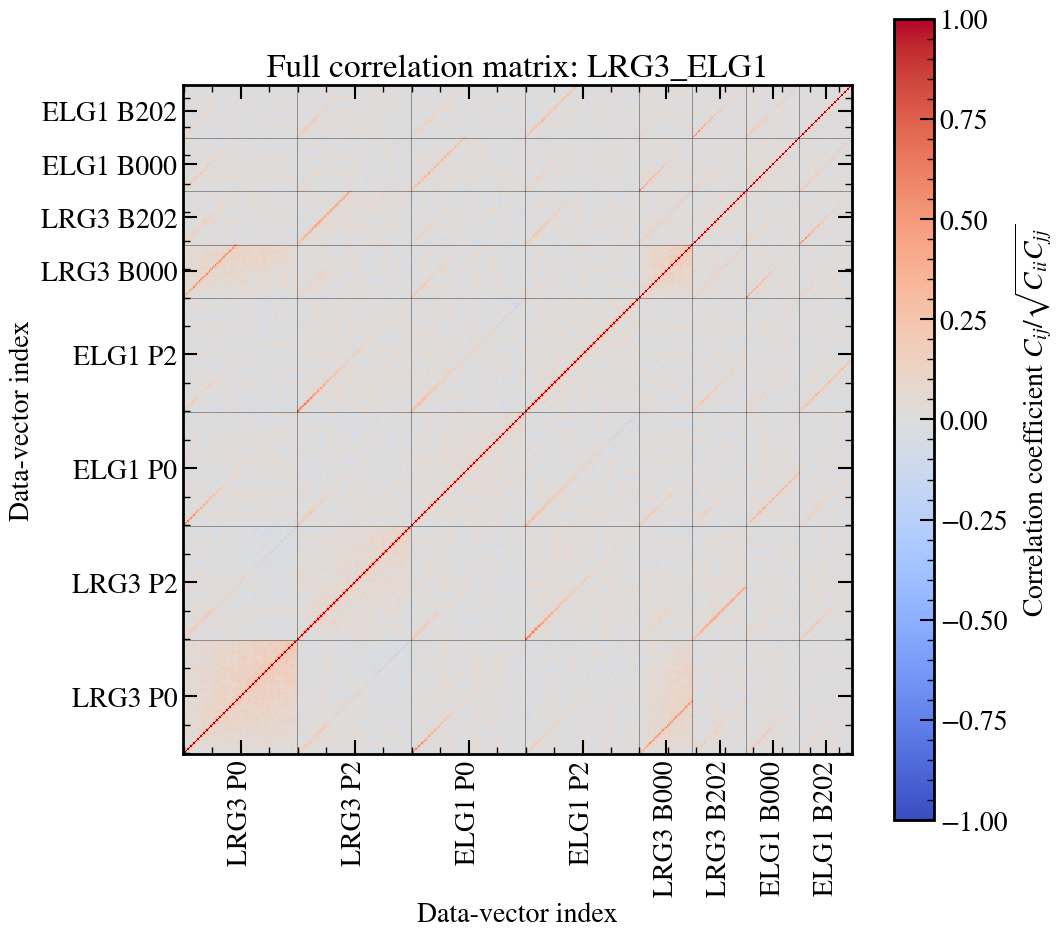

In [78]:
fig, ax, R_LRG3_ELG1, cov_layout_LRG3_ELG1 = plot_block_correlation_matrix(
    engine,
    block_name='LRG3_ELG1',
)
plt.show()

In [26]:
def plot_joint_block_data_with_errors(
    engine,
    block_name='LRG3_ELG1',
    stats=('mesh2_spectrum', 'mesh3_spectrum'),
    bispectrum_x='index',
    multiply_by_k=True,
    figsize_per_panel=(6.5, 3.2),
):
    """
    Plot the data vectors in a joint block with errorbars from the full combined covariance.

    Parameters
    ----------
    engine : DESIChi2Engine
        Engine containing a joint block such as 'LRG3_ELG1'.
    block_name : str
        Name of the likelihood block to plot.
    stats : tuple
        Statistics to plot.
    bispectrum_x : {'index', 'k1', 'kmean'}
        X-axis choice for bispectrum panels.
    multiply_by_k : bool
        If True, plot k * value and k * sigma. For bispectrum with 2D k coordinates,
        use kmean = 0.5 * (k1 + k2) as the prefactor.
    figsize_per_panel : tuple
        Width and height per panel.

    Returns
    -------
    fig, axes, cov_layout
    """
    block = get_block(engine, block_name)
    cov_layout = extract_block_covariance_layout(engine, block_name)

    C = np.asarray(cov_layout['matrix'], dtype=float)
    std_full = np.sqrt(np.diag(C))

    # Keep only requested stats
    plot_items = [
        item for item in cov_layout['layout']
        if item['stat'] in stats
    ]

    n_panels = len(plot_items)

    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=(figsize_per_panel[0], figsize_per_panel[1] * n_panels),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, item in zip(axes, plot_items):
        component_tracer = item['component_tracer']
        stat_name = item['stat']
        ell = item['ell']
        k = np.asarray(item['k'])
        sl = item['slice']

        # Data and diagonal errors from the full combined covariance
        y = np.asarray(
            block.data_objects[
                next(
                    i for i, spec in enumerate(block.observable_specs)
                    if spec['component_tracer'] == component_tracer
                    and spec['stat'] == stat_name
                )
            ].get(ells=ell).values('value'),
            dtype=float,
        ).reshape(-1)

        yerr = std_full[sl]

        # Choose x-axis
        if k.ndim == 1:
            x = k
            kpref = k
            xlabel = r"$k\,[h\,{\rm Mpc}^{-1}]$"
        
        elif k.ndim == 2 and k.shape[1] == 2:
            if bispectrum_x == 'k1':
                x = k[:, 0]
                xlabel = r"$k_1\,[h\,{\rm Mpc}^{-1}]$"
            elif bispectrum_x == 'kmean':
                x = 0.5 * (k[:, 0] + k[:, 1])
                xlabel = r"$(k_1+k_2)/2\,[h\,{\rm Mpc}^{-1}]$"
            else:
                x = np.arange(len(y))
                xlabel = "triangle bin index"
        
            kpref = 0.5 * (k[:, 0] + k[:, 1])
        
        else:
            x = np.arange(len(y))
            kpref = np.ones_like(y)
            xlabel = "bin index"

        if multiply_by_k:
            if stat_name == 'mesh2_spectrum':
                weight = kpref
                ylabel = r"$k\,P_\ell(k)$"
        
            elif stat_name == 'mesh3_spectrum':
                weight = kpref**2
                ylabel = r"$k^2\,B_{\ell_1\ell_2L}$"
        
            else:
                weight = np.ones_like(y)
                ylabel = "value"
        
            y_plot = weight * y
            yerr_plot = np.abs(weight) * yerr
        
        else:
            y_plot = y
            yerr_plot = yerr
            ylabel = "value"

        ax.errorbar(
            x,
            y_plot,
            yerr=yerr_plot,
            fmt='o',
            ms=3,
            capsize=2,
            label='data',
        )

        ell_label = ''.join(map(str, ell)) if isinstance(ell, tuple) else str(ell)
        ax.set_title(f"{block_name}: {component_tracer}, {stat_name}, ell={ell_label}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend()

    fig.tight_layout()
    return fig, axes, cov_layout

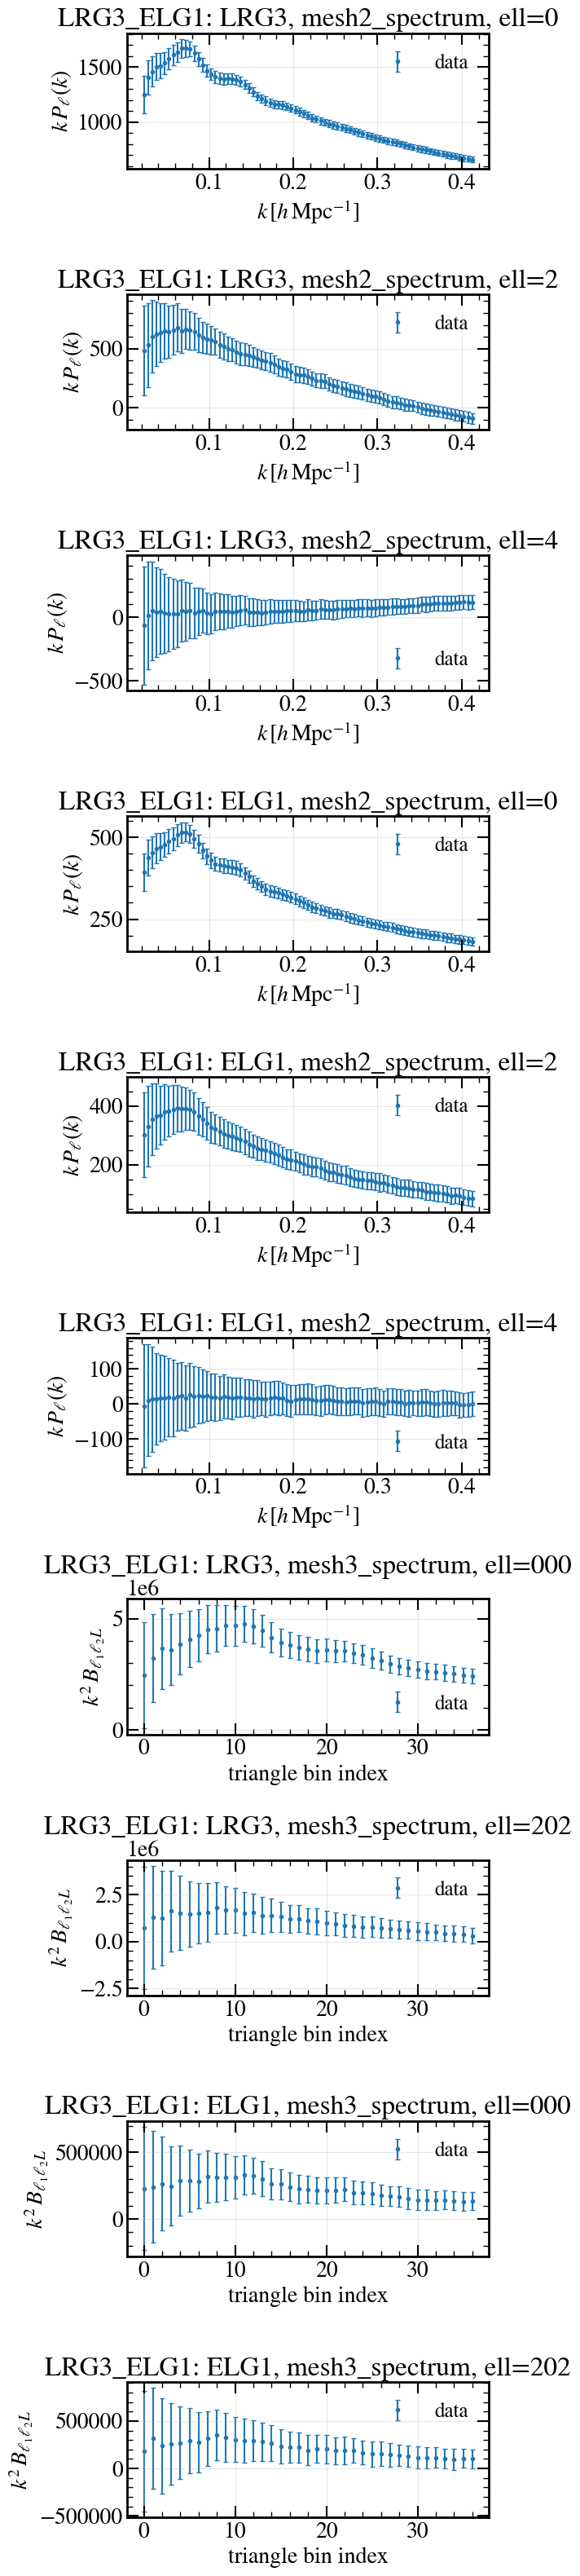

In [29]:
fig, axes, cov_layout_LRG3_ELG1 = plot_joint_block_data_with_errors(
    engine,
    block_name='LRG3_ELG1',
    stats=('mesh2_spectrum', 'mesh3_spectrum'),
    bispectrum_x='index',
    multiply_by_k=True,
)

plt.show()

### 5.3 Check individual mocks

In [79]:
import re
from pathlib import Path
from collections import defaultdict


def _mock_index_from_path(fn):
    """
    Extract mock index from a path containing .../mock{imock}/...
    """
    match = re.search(r"/mock(\d+)(?:/|$)", str(fn))
    if match is None:
        return None
    return int(match.group(1))


def _format_zrange_token(zrange):
    """
    Format zrange like the file names, e.g. (0.8, 1.1) -> 'z0.8-1.1'.
    """
    return f"z{float(zrange[0]):.1f}-{float(zrange[1]):.1f}"


def _component_path_token(component_tracer):
    """
    Return path tokens used to identify files for a component tracer such as LRG3 or ELG1.
    """
    tracer, zrange = fs_tools.get_full_tracer_zrange(component_tracer)
    return tracer, _format_zrange_token(zrange)


def _get_block_specs(block):
    """
    Return observable specs for both old single-tracer and new joint-block engines.
    """
    if hasattr(block, "observable_specs"):
        return list(block.observable_specs)

    # Fallback for older independent-tracer engine
    return [
        {
            "component_tracer": block.tracer,
            "stat": stat_name,
        }
        for stat_name in block.stat_names
    ]


def _get_data_object_for_spec(block, component_tracer, stat_name):
    """
    Return the selected data object corresponding to one component tracer/stat pair.
    """
    specs = _get_block_specs(block)

    matches = [
        i for i, spec in enumerate(specs)
        if spec["component_tracer"] == component_tracer
        and spec["stat"] == stat_name
    ]

    if len(matches) != 1:
        raise KeyError(
            f"Expected one data object for ({component_tracer}, {stat_name}), "
            f"found {len(matches)}."
        )

    return block.data_objects[matches[0]]


def collect_covariance_mock_files_for_block(engine, block_name):
    """
    Collect covariance mock files used by one likelihood block.

    For a joint block such as LRG3_ELG1, this returns files separately for
    each component tracer/stat pair and keeps only the common mock indices.

    Returns
    -------
    out : dict
        {
          'used_imocks': [...],
          'files': {
              ('LRG3', 'mesh2_spectrum'): {imock: Path(...), ...},
              ('ELG1', 'mesh2_spectrum'): {imock: Path(...), ...},
              ('LRG3', 'mesh3_spectrum'): {imock: Path(...), ...},
              ('ELG1', 'mesh3_spectrum'): {imock: Path(...), ...},
          }
        }
    """
    block = get_block(engine, block_name)
    specs = _get_block_specs(block)

    cov_version = str(block.file_info.get("covariance_version", ""))
    calls = block.file_info.get("existing_calls", [])

    files = {}

    for spec in specs:
        component = spec["component_tracer"]
        stat = spec["stat"]

        simple_tracer, ztoken = _component_path_token(component)
        key = (component, stat)

        files[key] = {}

        for call in calls:
            kind = call["kwargs"].get("kind", "")

            if kind != stat:
                continue

            for fn in call["existing"]:
                fn = Path(fn)
                s = str(fn)

                # Keep only covariance-version files, not the data files.
                if cov_version not in s:
                    continue

                # Require the component tracer and redshift-bin token in the path.
                if f"_{simple_tracer}_" not in s:
                    continue
                if ztoken not in s:
                    continue

                imock = _mock_index_from_path(fn)
                if imock is not None:
                    files[key][imock] = fn

    # The covariance is built from the intersection of mocks available for all observables.
    index_sets = [set(v.keys()) for v in files.values()]

    if not index_sets:
        used_imocks = []
    else:
        used_imocks = sorted(set.intersection(*index_sets))

    return {
        "used_imocks": used_imocks,
        "files": files,
    }


def _read_mock_leaf_matched(fn, data_obj, ell):
    """
    Read one covariance mock file, match it to the selected data object,
    and return k and value for one multipole.
    """
    obs = types.read(fn)

    # Preferred: match the full observable to the selected data layout.
    try:
        obs = obs.match(data_obj)
        leaf = obs.get(ells=ell)
    except Exception:
        # Fallback: select leaf first, then try to match the leaf.
        leaf = obs.get(ells=ell)
        try:
            leaf = leaf.match(data_obj.get(ells=ell))
        except Exception:
            pass

    k = np.asarray(leaf.coords("k"))
    y = np.asarray(leaf.values("value"), dtype=float).reshape(-1)

    return k, y


def _mock_plot_x_and_weight(k, stat_name, bispectrum_x="index", weight_data=True):
    """
    Choose x-axis and plotting weight.

    If weight_data=True:
      - P(k) is plotted as k P(k)
      - B(k) is plotted as k_mean^2 B(k)
    """
    k = np.asarray(k)

    if k.ndim == 1:
        x = k
        kpref = k
        xlabel = r"$k\,[h\,{\rm Mpc}^{-1}]$"

    elif k.ndim == 2 and k.shape[1] == 2:
        kmean = 0.5 * (k[:, 0] + k[:, 1])

        if bispectrum_x == "k1":
            x = k[:, 0]
            xlabel = r"$k_1\,[h\,{\rm Mpc}^{-1}]$"
        elif bispectrum_x == "kmean":
            x = kmean
            xlabel = r"$(k_1+k_2)/2\,[h\,{\rm Mpc}^{-1}]$"
        else:
            x = np.arange(k.shape[0])
            xlabel = "triangle bin index"

        kpref = kmean

    else:
        x = np.arange(k.shape[0])
        kpref = np.ones_like(x, dtype=float)
        xlabel = "bin index"

    if not weight_data:
        weight = np.ones_like(kpref, dtype=float)
        ylabel_suffix = "value"
    elif stat_name == "mesh2_spectrum":
        weight = kpref
        ylabel_suffix = r"$kP_\ell(k)$"
    elif stat_name == "mesh3_spectrum":
        weight = kpref**2
        ylabel_suffix = r"$k^2B_{\ell_1\ell_2L}$"
    else:
        weight = np.ones_like(kpref, dtype=float)
        ylabel_suffix = "value"

    return x, weight, xlabel, ylabel_suffix


def plot_covariance_mocks_for_block(
    engine,
    block_name="LRG3_ELG1",
    max_mocks=None,
    bispectrum_x="index",
    weight_data=True,
    alpha=0.08,
    lw=0.7,
    figsize_per_panel=(5.5, 3.2),
):
    """
    Plot all covariance mocks used for a block, split into P0, P2, B000, B202.

    For a joint block like LRG3_ELG1, rows are component tracers and columns are:
        P0, P2, B000, B202.

    Parameters
    ----------
    engine : DESIChi2Engine
        Engine loaded with cache_dir=None if you want path recording to be complete.
    block_name : str
        Likelihood block to inspect, e.g. 'LRG3_ELG1' or 'LRG2'.
    max_mocks : int or None
        If None, plot all common covariance mocks. If int, plot only first max_mocks.
    bispectrum_x : {'index', 'k1', 'kmean'}
        X-axis choice for bispectrum panels.
    weight_data : bool
        If True, plot kP for power and k^2B for bispectrum.
    alpha : float
        Alpha for individual mock curves.
    lw : float
        Line width for individual mock curves.

    Returns
    -------
    fig, axes, info
        info contains the used mock indices and file map.
    """
    block = get_block(engine, block_name)
    specs = _get_block_specs(block)

    # Unique component tracers in block order.
    component_tracers = []
    for spec in specs:
        component = spec["component_tracer"]
        if component not in component_tracers:
            component_tracers.append(component)

    targets = [
        ("mesh2_spectrum", 0, r"$P_0$"),
        ("mesh2_spectrum", 2, r"$P_2$"),
        ("mesh3_spectrum", (0, 0, 0), r"$B_{000}$"),
        ("mesh3_spectrum", (2, 0, 2), r"$B_{202}$"),
    ]

    info = collect_covariance_mock_files_for_block(engine, block_name)
    used_imocks = info["used_imocks"]

    if max_mocks is not None:
        used_imocks_plot = used_imocks[:max_mocks]
    else:
        used_imocks_plot = used_imocks

    if len(used_imocks_plot) == 0:
        raise RuntimeError(
            f"No covariance mock files found for block={block_name!r}. "
            "Make sure the engine was loaded with cache_dir=None and that "
            "block.file_info contains covariance-version paths."
        )

    nrow = len(component_tracers)
    ncol = len(targets)

    fig, axes = plt.subplots(
        nrow,
        ncol,
        figsize=(figsize_per_panel[0] * ncol, 2 * figsize_per_panel[1] * nrow),
        squeeze=False,
    )

    for irow, component in enumerate(component_tracers):
        for icol, (stat_name, ell, label) in enumerate(targets):
            ax = axes[irow, icol]

            data_obj = _get_data_object_for_spec(block, component, stat_name)
            file_map = info["files"].get((component, stat_name), {})

            mock_values = []
            x_ref = None
            weight_ref = None
            xlabel = None
            ylabel = None

            for imock in used_imocks_plot:
                fn = file_map.get(imock, None)
                if fn is None:
                    continue

                k, y = _read_mock_leaf_matched(fn, data_obj, ell)
                x, weight, xlabel, ylabel = _mock_plot_x_and_weight(
                    k,
                    stat_name,
                    bispectrum_x=bispectrum_x,
                    weight_data=weight_data,
                )

                y_plot = weight * y

                ax.plot(
                    x,
                    y_plot,
                    color="0.55",
                    alpha=alpha,
                    lw=lw,
                    rasterized=True,
                )

                mock_values.append(y_plot)
                if x_ref is None:
                    x_ref = x
                    weight_ref = weight

            # Overlay covariance-mock mean.
            if mock_values:
                mock_values = np.asarray(mock_values)
                mean_mock = np.mean(mock_values, axis=0)
                ax.plot(x_ref, mean_mock, color="k", lw=2.0, label="mock mean")

            # Overlay selected data vector for reference.
            try:
                k_data = np.asarray(data_obj.get(ells=ell).coords("k"))
                y_data = np.asarray(data_obj.get(ells=ell).values("value"), dtype=float).reshape(-1)
                x_data, weight_data_arr, _, _ = _mock_plot_x_and_weight(
                    k_data,
                    stat_name,
                    bispectrum_x=bispectrum_x,
                    weight_data=weight_data,
                )
                ax.plot(
                    x_data,
                    weight_data_arr * y_data,
                    color="C3",
                    lw=1.8,
                    label="data",
                )
            except Exception:
                pass

            ax.set_title(f"{component} {label} | {len(used_imocks_plot)} mocks")
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.grid(alpha=0.3)

            if irow == 0 and icol == 0:
                ax.legend()

    fig.suptitle(
        f"Covariance mocks used for block {block_name} "
        f"({len(used_imocks)} common mock realizations)",
        y=1.01,
    )
    fig.tight_layout()

    return fig, axes, info

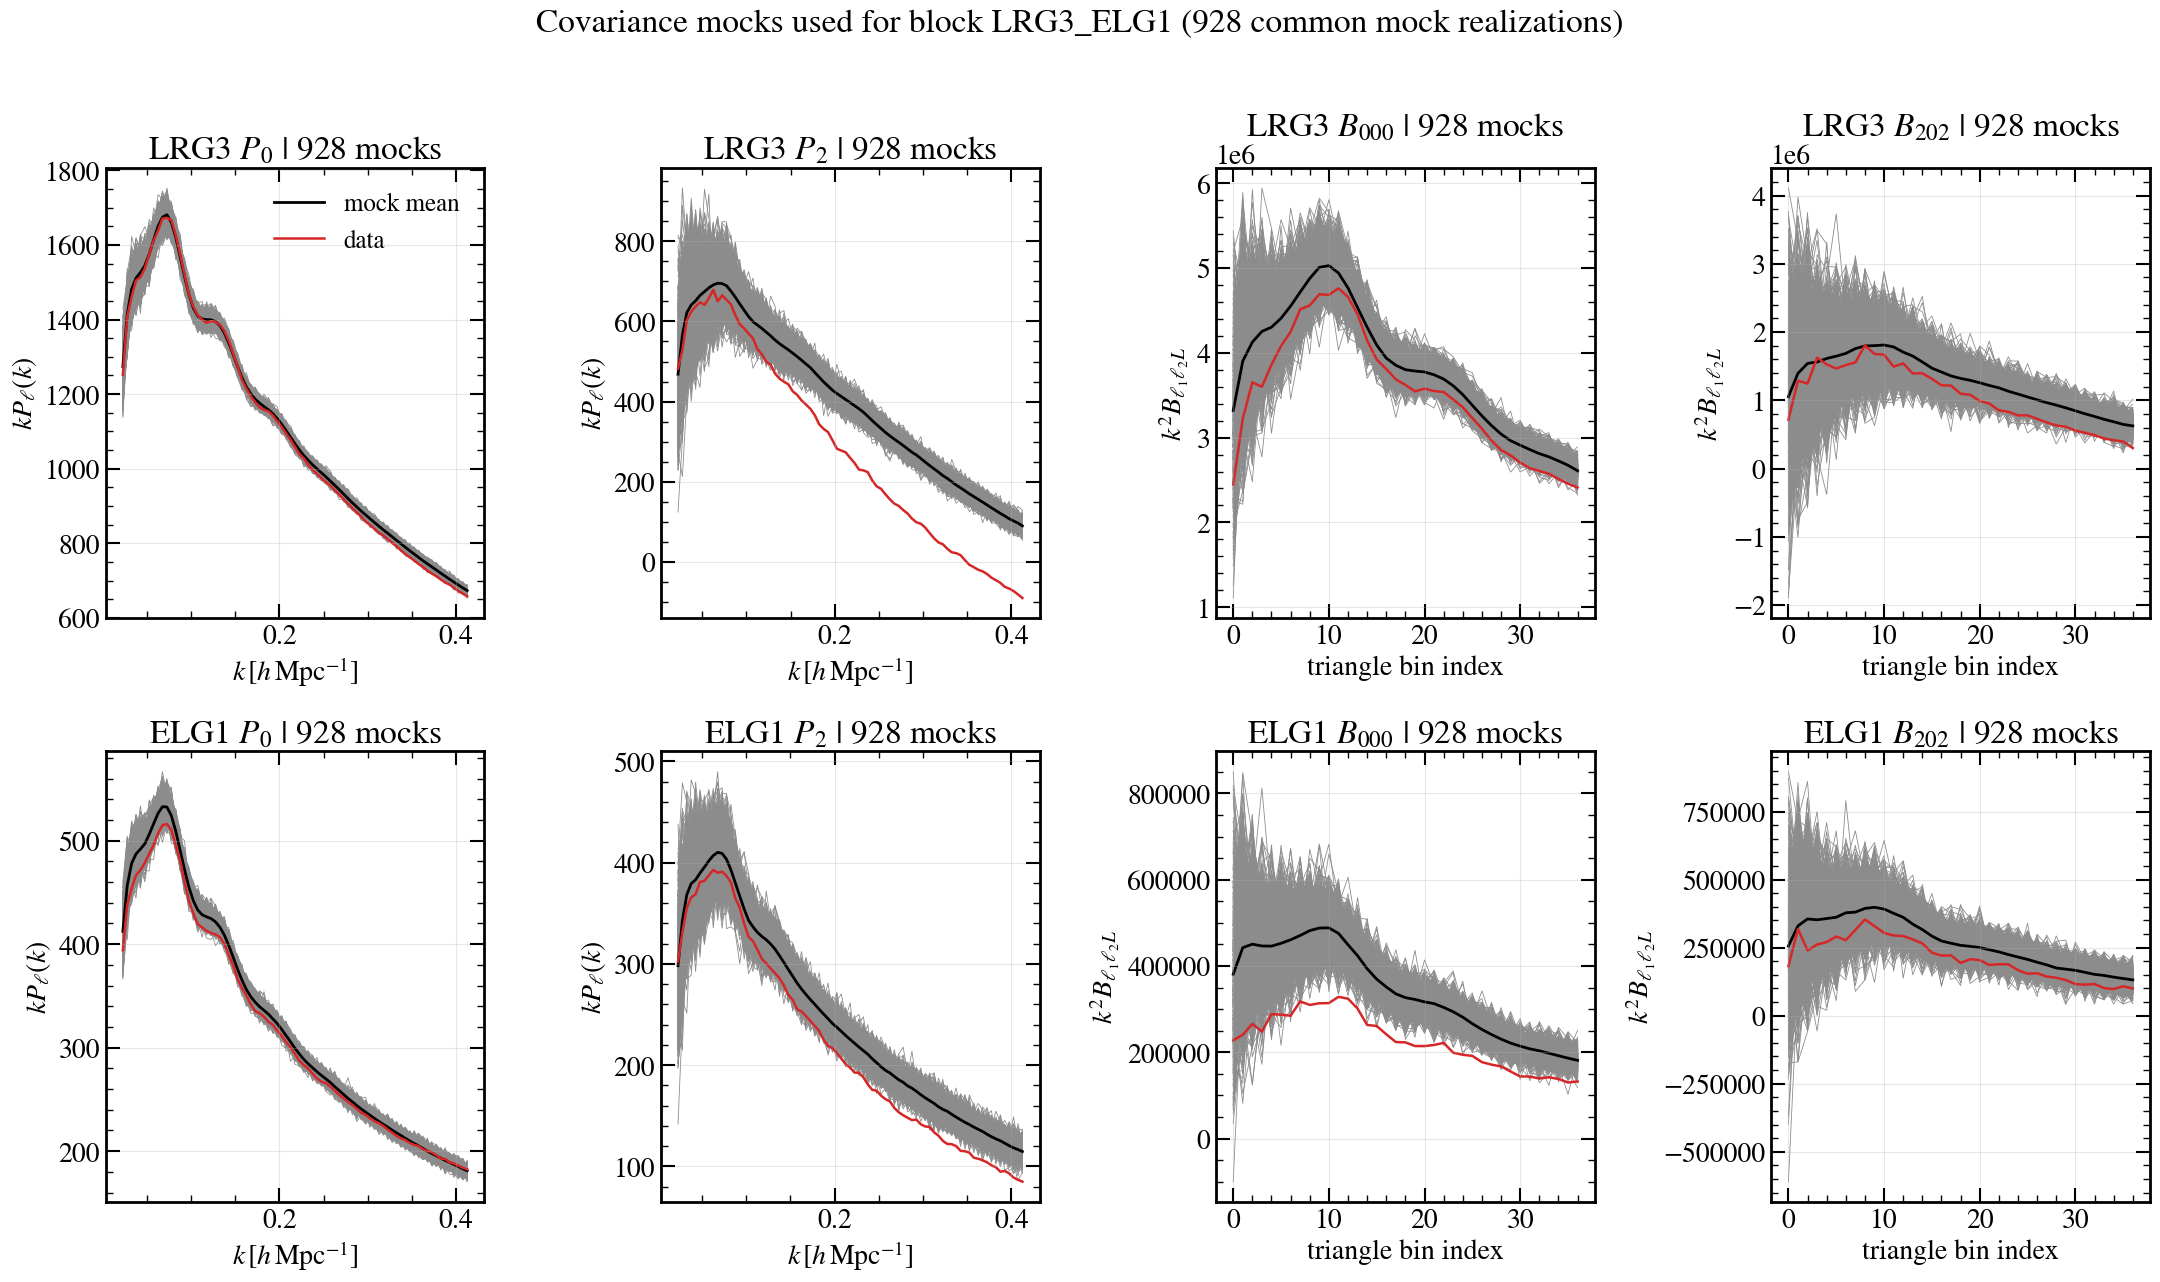

In [81]:
fig, axes, glam_mock_info = plot_covariance_mocks_for_block(
    engine,
    block_name='LRG3_ELG1',
    max_mocks=None,        # plot all mocks
    bispectrum_x='index',
    weight_data=True,      # P -> kP, B -> k^2B
    alpha=1.,
    lw=0.6,
)

plt.show()

## 6. Example model construction

This example uses the mean of box measurements as a **proxy theory model**. In practice you should replace this section with your own model evaluation.

### Important
- For `mesh2_spectrum`, the model can be supplied either on its own `k` grid as `(k, P_ell)` or directly on the window grid provided in the previous cell.
- For `mesh3_spectrum`, the theory basis is the **full six Sugiyama multipoles**:
  - `(0,0,0), (0,2,2), (1,1,0), (1,1,2), (2,2,0), (2,2,2)`
- For multi-tracer runs, the top-level model dictionary must be keyed by tracer name as you will see as an eg in the following cell.


In [7]:
# ------------------------------------------------------------------
# Read box measurements to use here only as a stand-in theory model
# ------------------------------------------------------------------

box_stats_dir = Path('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/box/')

nmocks = 25
zrange = [0.6, 0.8]
zsnap = box_tools.get_zsnap_from_z('LRG', zrange, version='abacus-2ndgen')

# Power-spectrum box mocks
pow_fns = [
    box_tools.get_box_stats_fn(
        stats_dir=box_stats_dir,
        kind='mesh2_spectrum',
        version='abacus-2ndgen',
        tracer='LRG',
        zsnap=zsnap,
        region='GCcomb',
        weight='default-FKP',
        cosmo='000',
        hod=None,
        los='z',
        basis='sugiyama',
        imock=imock,
    )
    for imock in range(nmocks)
]
mocks_box_pow = [types.read(fn) for fn in pow_fns if fn.exists()]
mean_box_pow = types.mean(mocks_box_pow)

# Bispectrum box mocks
bis_fns = [
    box_tools.get_box_stats_fn(
        stats_dir=box_stats_dir,
        kind='mesh3_spectrum',
        version='abacus-2ndgen',
        tracer='LRG',
        zsnap=zsnap,
        region='GCcomb',
        weight='default-FKP',
        cosmo='000',
        hod=None,
        los='z',
        basis='sugiyama',
        imock=imock,
    )
    for imock in range(nmocks)
]
mocks_box_bis = [types.read(fn) for fn in bis_fns if fn.exists()]
mean_box_bis = types.mean(mocks_box_bis)

# ------------------------------------------------------------------
# Extract the box multipoles
# ------------------------------------------------------------------

# Power spectrum
k_pow_th = np.asarray(mean_box_pow.get(ells=0).coords('k'), dtype=float)
nmodes_pow = np.asarray(mean_box_pow.get(ells=0).coords('nmodes'))

p0_th = np.asarray(mean_box_pow.get(ells=0).values('value'), dtype=float)
p2_th = np.asarray(mean_box_pow.get(ells=2).values('value'), dtype=float)
p4_th = np.asarray(mean_box_pow.get(ells=4).values('value'), dtype=float)

# Optional masking of empty power bins
mask_pow = np.asarray(nmodes_pow) > 0
k_pow_fit = k_pow_th[mask_pow]
p0_fit = p0_th[mask_pow]
p2_fit = p2_th[mask_pow]
p4_fit = p4_th[mask_pow]

# Bispectrum grid
k1_th = np.asarray(mean_box_bis.get(ells=(0, 0, 0)).unravel().coords('k1'), dtype=float)
k2_th = np.asarray(mean_box_bis.get(ells=(0, 0, 0)).unravel().coords('k2'), dtype=float)

b000_th = np.asarray(mean_box_bis.get(ells=(0, 0, 0)).unravel().values('value'), dtype=float)
b022_th = np.asarray(mean_box_bis.get(ells=(0, 2, 2)).unravel().values('value'), dtype=float)
b110_th = np.asarray(mean_box_bis.get(ells=(1, 1, 0)).unravel().values('value'), dtype=float)
b112_th = np.asarray(mean_box_bis.get(ells=(1, 1, 2)).unravel().values('value'), dtype=float)
b220_th = np.asarray(mean_box_bis.get(ells=(2, 2, 0)).unravel().values('value'), dtype=float)
b222_th = np.asarray(mean_box_bis.get(ells=(2, 2, 2)).unravel().values('value'), dtype=float)

# ------------------------------------------------------------------
# Build one single-tracer model dictionary
# I repeat here the same model twice for conveneince but you should
# compute the model at the two effective redshifts
# ------------------------------------------------------------------

model = {
    'LRG1': {
        'mesh2_spectrum': {
            0: (k_pow_fit, p0_fit),
            2: (k_pow_fit, p2_fit),
            4: (k_pow_fit, p4_fit),
                          },
        'mesh3_spectrum': {
            (0, 0, 0): (k1_th, k2_th, b000_th),
            (0, 2, 2): (k1_th, k2_th, b022_th),
            (1, 1, 0): (k1_th, k2_th, b110_th),
            (1, 1, 2): (k1_th, k2_th, b112_th),
            (2, 2, 0): (k1_th, k2_th, b220_th),
            (2, 2, 2): (k1_th, k2_th, b222_th),
        },
    },
    'LRG2': {
        'mesh2_spectrum': {
            0: (k_pow_fit, p0_fit),
            2: (k_pow_fit, p2_fit),
            4: (k_pow_fit, p4_fit),
                          },
        'mesh3_spectrum': {
            (0, 0, 0): (k1_th, k2_th, b000_th),
            (0, 2, 2): (k1_th, k2_th, b022_th),
            (1, 1, 0): (k1_th, k2_th, b110_th),
            (1, 1, 2): (k1_th, k2_th, b112_th),
            (2, 2, 0): (k1_th, k2_th, b220_th),
            (2, 2, 2): (k1_th, k2_th, b222_th),
                          },
    }
}

## 7. Compute $\chi^2$

The total $\chi^2$ is the sum of the per-tracer contributions. The engine can also return the per-tracer convolved observables, residuals, and data/theory vectors if you need them for diagnostics.


In [8]:
parts = engine.chi2_per_tracer(model)

for tracer, info in parts.items():
    print(f"{tracer}: chi2 = {info['chi2']:.6f}")

chi2_total = engine.chi2(model)
print(f"\nTotal chi2 = {chi2_total:.6f}")

KeyError: 'Missing model for tracer LRG3'

## 8. Plot data vs convolved theory

These plots use the **selected data basis** and the convolved theory matched to that same basis. The lower panels show the per-bin pull using the diagonal covariance.


In [ ]:
plot_stat_multipoles(engine, model, tracer='LRG2', stat_name='mesh2_spectrum', figsize=(8, 8))
plot_stat_multipoles(engine, model, tracer='LRG2', stat_name='mesh3_spectrum', figsize=(8, 8))

# Uncomment these if you want the same plots for additional tracers
# plot_stat_multipoles(engine, model, tracer='LRG2', stat_name='mesh2_spectrum', figsize=(8, 4.8))
# plot_stat_multipoles(engine, model, tracer='LRG2', stat_name='mesh3_spectrum', figsize=(8, 4.8))

plt.show()

## 9. Inspect the resolved files

This is useful to confirm which HF mocks were used as data, which holimocks entered the covariance, and which window files were loaded.


In [ ]:
engine.print_file_info('LRG1')
# engine.print_file_info('LRG2')

## 10. Export data / window / covariance arrays

These helpers are convenient if you want to:
- work outside the engine
- save NumPy arrays for writing your own likelihood functions


### Helper functions

In [9]:
import json
import h5py
from pathlib import Path


def _ell_to_key(ell):
    """
    Convert an ell label into a safe HDF5 group name.

    Examples
    --------
    0 -> 'ell_0'
    (2, 0, 2) -> 'ell_2_0_2'
    """
    if isinstance(ell, tuple):
        return "ell_" + "_".join(str(x) for x in ell)
    return f"ell_{ell}"


def _ell_to_json(ell):
    """
    Store ell labels losslessly as JSON.
    """
    if isinstance(ell, tuple):
        return json.dumps(list(ell))
    return json.dumps(ell)


def _json_default(obj):
    """
    JSON fallback for numpy scalars/arrays and Path objects.
    """
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    return str(obj)


def _write_dataset(group, name, value, compression=True):
    """
    Write a dataset, replacing an existing dataset with the same name.
    """
    if name in group:
        del group[name]

    value = np.asarray(value)

    # Scalars should not be compressed.
    if value.shape == ():
        return group.create_dataset(name, data=value)

    if compression:
        return group.create_dataset(
            name,
            data=value,
            compression="gzip",
            compression_opts=4,
            shuffle=True,
        )
    return group.create_dataset(name, data=value)


def _safe_values(obj, name):
    """
    Safely extract obj.values(name). Return None if unavailable.
    """
    try:
        return np.asarray(obj.values(name))
    except Exception:
        return None


def _safe_attrs(obj):
    """
    Convert lsstypes attrs into a JSON-serializable dictionary.
    """
    try:
        return dict(obj.attrs)
    except Exception:
        return {}


def _coord_size(k):
    """
    Number of vector entries represented by a coordinate array.

    For power spectrum, k is usually shape (N,).
    For bispectrum, k is usually shape (N, 2).
    """
    k = np.asarray(k)
    if k.ndim == 0:
        return 1
    return k.shape[0]


def _write_layout_from_observable(parent, name, observable, include_values=False):
    """
    Write per-ell k-coordinates and slices for an lsstypes observable-like object.

    Parameters
    ----------
    parent : h5py.Group
        Parent group.
    name : str
        Name of layout group to create, e.g. 'data_layout', 'observable_layout'.
    observable : lsstypes object
        Object with .ells and .get(ells=...).
    include_values : bool
        If True, also write the values for each ell and return the concatenated vector.

    Returns
    -------
    vector : np.ndarray or None
        Concatenated values if include_values=True, otherwise None.
    layout : list[dict]
        Python metadata list describing ordering and slices.
    """
    grp = parent.require_group(name)

    layout = []
    pieces = []
    start = 0

    for ell in observable.ells:
        ell_grp = grp.require_group(_ell_to_key(ell))
        leaf = observable.get(ells=ell)

        k = np.asarray(leaf.coords("k"))
        _write_dataset(ell_grp, "k", k)

        if include_values:
            value = np.asarray(leaf.values("value"), dtype=float).reshape(-1)
            _write_dataset(ell_grp, "value", value)
            n = len(value)
            pieces.append(value)
        else:
            n = _coord_size(k)

        # Optional fields commonly useful for theory/model construction.
        shotnoise = _safe_values(leaf, "shotnoise")
        if shotnoise is not None:
            _write_dataset(ell_grp, "shotnoise", shotnoise)

        nmodes = _safe_values(leaf, "nmodes")
        if nmodes is not None:
            _write_dataset(ell_grp, "nmodes", nmodes)

        attrs = _safe_attrs(leaf)
        ell_grp.attrs["attrs_json"] = json.dumps(attrs, default=_json_default)
        ell_grp.attrs["ell_json"] = _ell_to_json(ell)
        ell_grp.attrs["slice_start"] = int(start)
        ell_grp.attrs["slice_stop"] = int(start + n)

        layout.append({
            "ell": ell,
            "ell_key": _ell_to_key(ell),
            "slice_start": int(start),
            "slice_stop": int(start + n),
            "size": int(n),
            "k_shape": tuple(np.asarray(k).shape),
        })

        start += n

    vector = np.concatenate(pieces) if include_values and pieces else None
    grp.attrs["layout_json"] = json.dumps(layout, default=_json_default)
    grp.attrs["total_size"] = int(start)

    return vector, layout


def _write_window_group(parent, stat_name, window_obj):
    """
    Write one statistic's window matrix and both its observable/theory layouts.

    The window matrix maps:

        theory_vector_for_this_stat -> convolved_observable_vector_for_this_stat

    in the exact order described by the saved theory_layout and observable_layout.
    """
    stat_grp = parent.require_group(stat_name)

    W = np.asarray(window_obj.value(), dtype=float)
    _write_dataset(stat_grp, "matrix", W)

    _, obs_layout = _write_layout_from_observable(
        stat_grp,
        "observable_layout",
        window_obj.observable,
        include_values=False,
    )

    _, th_layout = _write_layout_from_observable(
        stat_grp,
        "theory_layout",
        window_obj.theory,
        include_values=False,
    )

    stat_grp.attrs["matrix_shape"] = json.dumps(tuple(W.shape))
    stat_grp.attrs["observable_layout_json"] = json.dumps(obs_layout, default=_json_default)
    stat_grp.attrs["theory_layout_json"] = json.dumps(th_layout, default=_json_default)


def _build_data_vector_and_layout(block, tracer_grp):
    """
    Write data arrays for one tracer block and return the full concatenated data vector.
    """
    data_grp = tracer_grp.require_group("data")

    full_pieces = []
    full_layout = []
    global_start = 0

    for stat_name, data_obj in zip(block.stat_names, block.data_objects):
        stat_grp = data_grp.require_group(stat_name)
        stat_vector, stat_layout = _write_layout_from_observable(
            stat_grp,
            "ells",
            data_obj,
            include_values=True,
        )

        _write_dataset(stat_grp, "vector", stat_vector)

        for item in stat_layout:
            item = dict(item)
            item["stat"] = stat_name
            item["global_slice_start"] = int(global_start + item["slice_start"])
            item["global_slice_stop"] = int(global_start + item["slice_stop"])
            full_layout.append(item)

        full_pieces.append(stat_vector)
        global_start += len(stat_vector)

    full_vector = np.concatenate(full_pieces)
    _write_dataset(data_grp, "vector", full_vector)
    data_grp.attrs["layout_json"] = json.dumps(full_layout, default=_json_default)
    data_grp.attrs["total_size"] = int(len(full_vector))

    return full_vector, full_layout


def _write_covariance_group(tracer_grp, block, data_layout):
    """
    Write the full covariance matrix for one tracer block.

    This full matrix is the authoritative covariance object. It includes:
      - power-power covariance,
      - bispectrum-bispectrum covariance,
      - power-bispectrum cross-covariance,

    for this tracer, in the exact same ordering as /data/vector.
    """
    cov_grp = tracer_grp.require_group("covariance")

    C = np.asarray(block.covariance, dtype=float)
    _write_dataset(cov_grp, "matrix", C)

    cov_grp.attrs["shape"] = json.dumps(tuple(C.shape))
    cov_grp.attrs["data_layout_json"] = json.dumps(data_layout, default=_json_default)
    cov_grp.attrs["attrs_json"] = json.dumps(dict(block.covariance_attrs), default=_json_default)

    # Convenience diagonal errors in the full data-vector ordering.
    _write_dataset(cov_grp, "std", np.sqrt(np.diag(C)))


def _write_windows_group(tracer_grp, block):
    """
    Write all window matrices for one tracer block.
    """
    windows_grp = tracer_grp.require_group("windows")

    for stat_name, window_obj in zip(block.stat_names, block.window_objects):
        _write_window_group(windows_grp, stat_name, window_obj)

def _write_tracer_metadata(tracer_grp, block):
    """
    Write per-tracer metadata needed by external theory/model codes.

    Stored quantities
    -----------------
    zeff : float
        Effective redshift, read from the power-spectrum window observable.
    nmean : float
        Number density inferred from the monopole power-spectrum shot noise:
            nmean = 1 / shotnoise_P0[0]
    power_shotnoise : array
        Shot-noise array stored in the power-spectrum monopole data object.
    bispectrum_poisson : array
        Bispectrum Poisson/shot-noise term stored in the B000 data object.
    """
    meta_grp = tracer_grp.require_group("metadata")

    # Defaults in case a stat is absent.
    zeff = np.nan
    nmean = np.nan
    power_shotnoise = np.array([], dtype=float)
    bispectrum_poisson = np.array([], dtype=float)

    # Power-spectrum metadata
    if "mesh2_spectrum" in block.stat_names:
        i_pow = block.stat_names.index("mesh2_spectrum")
        data_pow = block.data_objects[i_pow]
        window_pow = block.window_objects[i_pow]

        try:
            zeff = float(window_pow.observable.get(ells=0).attrs["zeff"])
        except Exception:
            zeff = np.nan

        try:
            power_shotnoise = np.asarray(
                data_pow.get(ells=0).values("shotnoise"),
                dtype=float,
            )
            nmean = float(1.0 / power_shotnoise.flat[0])
        except Exception:
            power_shotnoise = np.array([], dtype=float)
            nmean = np.nan

    # Bispectrum metadata
    if "mesh3_spectrum" in block.stat_names:
        i_bis = block.stat_names.index("mesh3_spectrum")
        data_bis = block.data_objects[i_bis]

        try:
            bispectrum_poisson = np.asarray(
                data_bis.get(ells=(0, 0, 0)).values("shotnoise"),
                dtype=float,
            )
        except Exception:
            bispectrum_poisson = np.array([], dtype=float)

    _write_dataset(meta_grp, "zeff", np.asarray(zeff))
    _write_dataset(meta_grp, "nmean", np.asarray(nmean))
    _write_dataset(meta_grp, "power_shotnoise", power_shotnoise)
    _write_dataset(meta_grp, "bispectrum_poisson", bispectrum_poisson)

    meta_grp.attrs["description"] = (
        "Metadata useful for external model evaluation. "
        "nmean is inferred as 1 / power_shotnoise[0]. "
        "bispectrum_poisson is read from data_bis.get(ells=(0,0,0)).values('shotnoise')."
    )

def export_engine_chi2_inputs(
    engine,
    filename,
    tracers=None,
    kranges=None,
    description=None,
    compression=True,
):
    """
    Export all ingredients needed to compute chi2 outside this notebook.

    Parameters
    ----------
    engine : DESIChi2Engine
        Loaded engine.
    filename : str or Path
        Output HDF5 filename.
    tracers : list[str] or None
        Tracers to export. If None, export all tracers in the engine.
    kranges : dict or None
        Optional KRANGES dictionary used to select the data.
    description : str or None
        Optional human-readable description stored in the file.
    compression : bool
        Whether to gzip-compress large datasets.

    File structure
    --------------
    /tracers/{tracer}/data/vector
        Full concatenated data vector for that tracer.

    /tracers/{tracer}/data/{stat}/ells/{ell_key}/k
        k-coordinates for that stat/ell in data space.

    /tracers/{tracer}/data/{stat}/ells/{ell_key}/value
        Data values for that stat/ell.

    /tracers/{tracer}/covariance/matrix
        Full covariance matrix in the same order as data/vector.

    /tracers/{tracer}/windows/{stat}/matrix
        Window matrix for that statistic.

    /tracers/{tracer}/windows/{stat}/observable_layout
        k-coordinates and slices for the convolved observable vector.

    /tracers/{tracer}/windows/{stat}/theory_layout
        k-coordinates and slices for the unconvolved theory vector.

    Notes
    -----
    The exported covariance matrix is the central object. It preserves all
    cross-covariance between power spectrum and bispectrum bins within a tracer.
    The current engine treats different tracers as independent likelihood blocks,
    so the total chi2 is the sum over tracer-level chi2 values.
    """
    filename = Path(filename)

    if tracers is None:
        tracers = list(engine.tracers)

    blocks_by_tracer = {block.tracer: block for block in engine.blocks}

    with h5py.File(filename, "w") as h5:
        h5.attrs["format"] = "DESIChi2Engine export"
        h5.attrs["version"] = "1.0"
        h5.attrs["description"] = description or (
            "Inputs required to compute chi2 from external theory predictions."
        )
        h5.attrs["engine_version"] = str(engine.version)
        h5.attrs["covariance_version"] = str(engine.covariance_version)
        h5.attrs["stats"] = json.dumps(list(engine.stats))
        h5.attrs["tracers"] = json.dumps(list(tracers))
        h5.attrs["kranges_json"] = json.dumps(kranges, default=_json_default)
        h5.attrs["chi2_formula"] = (
            "For each tracer: chi2 = (d - m)^T C^{-1} (d - m), "
            "where m is built by applying each stat window to the corresponding "
            "unconvolved theory vector and concatenating in data/vector order. "
            "Total chi2 is the sum over tracers."
        )

        tracers_grp = h5.require_group("tracers")

        for tracer in tracers:
            if tracer not in blocks_by_tracer:
                raise KeyError(
                    f"Tracer {tracer} not found in engine. "
                    f"Available: {list(blocks_by_tracer)}"
                )

            block = blocks_by_tracer[tracer]
            tracer_grp = tracers_grp.require_group(tracer)

            tracer_grp.attrs["tracer"] = tracer
            tracer_grp.attrs["stat_names"] = json.dumps(list(block.stat_names))
            tracer_grp.attrs["covariance_attrs_json"] = json.dumps(
                dict(block.covariance_attrs),
                default=_json_default,
            )

            data_vector, data_layout = _build_data_vector_and_layout(block, tracer_grp)
            _write_covariance_group(tracer_grp, block, data_layout)
            _write_windows_group(tracer_grp, block)
            _write_tracer_metadata(tracer_grp, block)

            # Sanity check stored as metadata.
            tracer_grp.attrs["ndata"] = int(len(data_vector))
            tracer_grp.attrs["covariance_shape"] = json.dumps(tuple(block.covariance.shape))

    return filename

In [10]:
output_fn = export_engine_chi2_inputs(
    engine,
    filename="desi_chi2_inputs_all_tracers_glam_v2_altmtl_covariance.h5",
    tracers=['LRG1', 'LRG2', 'LRG3', 'ELG1', 'ELG2', 'QSO1'],
    kranges=KRANGES,
    description=(
        "DESI full-shape P_l and Sugiyama B_l inputs. "
        "Data from abacus-hf-dr2-v2-altmtl, covariance from glam-v2-altmtl. " #"Data from abacus-hf-dr2-v2-altmtl, covariance from holi-v3-altmtl. "
        "Includes full covariance per tracer and window matrices."
    ),
)

print(output_fn)

desi_chi2_inputs_all_tracers_glam_v2_altmtl_covariance.h5


In [ ]:
data_arrays = extract_data_arrays(engine, 'LRG1')
window_arrays = extract_window_arrays(engine, 'LRG1')
cov_arrays = extract_covariance_arrays(engine, 'LRG1')

# Data examples
k_p0 = data_arrays['mesh2_spectrum'][0]['k']
p0_data = data_arrays['mesh2_spectrum'][0]['value']

k_b000 = data_arrays['mesh3_spectrum'][(0, 0, 0)]['k']
b000_data = data_arrays['mesh3_spectrum'][(0, 0, 0)]['value']

# Window examples
W_pow = window_arrays['mesh2_spectrum']['matrix']
k_obs_p0 = window_arrays['mesh2_spectrum']['observable'][0]['k']
k_th_p0 = window_arrays['mesh2_spectrum']['theory'][0]['k']

W_bis = window_arrays['mesh3_spectrum']['matrix']
k_obs_b000 = window_arrays['mesh3_spectrum']['observable'][(0, 0, 0)]['k']
k_th_b000 = window_arrays['mesh3_spectrum']['theory'][(0, 0, 0)]['k']

# Covariance examples
C_full = cov_arrays['full_matrix']

C_pow = cov_arrays['per_stat']['mesh2_spectrum']['matrix']
k_cov_p0 = cov_arrays['per_stat']['mesh2_spectrum']['k'][0]
std_p0 = cov_arrays['per_stat']['mesh2_spectrum']['std'][0]

C_bis = cov_arrays['per_stat']['mesh3_spectrum']['matrix']
k_cov_b000 = cov_arrays['per_stat']['mesh3_spectrum']['k'][(0, 0, 0)]
std_b000 = cov_arrays['per_stat']['mesh3_spectrum']['std'][(0, 0, 0)]

# Covariance sub-block examples
C_P0P2 = cov_arrays['per_stat']['mesh2_spectrum']['subblocks'][0][2]
C_B000B202 = cov_arrays['per_stat']['mesh3_spectrum']['subblocks'][(0, 0, 0)][(2, 0, 2)]

print("Shapes:")
print("  C_full      =", C_full.shape)
print("  C_P0P2      =", C_P0P2.shape)
print("  C_B000B202  =", C_B000B202.shape)

## 11. Recover the concatenated data-vector ordering

This is the ordering used when flattening the selected observables into the data vector compared against the full covariance matrix.


In [ ]:
data_vec, layout = extract_concatenated_layout(engine, 'LRG1')

print("Concatenated data-vector length:", len(data_vec))
print("Layout entries:")
for item in layout:
    print(item['stat'], item['ell'], item['size'])